# $\bar{X}$ and $s$ / $s^2$ Control Charts, and a Deeper Dive into Process Capability

**STAT 7110 — Class 3**
*Dr. Austin Brown, Kennesaw State University*

### Table of Contents
1. [$\bar{X}$ and $s$ Charts](#xbar-s)
2. [$\bar{X}$ and $s^2$ Charts](#s2-chart)
3. [Additional Process Capability Indices and Techniques](#capability)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture:

#setwd("Slides//Week-3-S2-Charts-and-Process-Capability")

## Introduction

- In last week's class, we learned how to estimate a univariate process's mean and standard deviation using the sample mean, ($\hat{\mu} = \bar{X}$), and the mean of the sample ranges scaled by $d_2$, ($\hat{\sigma} = \bar{R}/d_2$).

- When we're estimating parameters in general, one of the properties we like an estimator to have is **consistency**. A consistent estimator is one where, as sample size increases, the estimator gets closer to the true value of the parameter.

- The sample range does **not** have this property. While the Montgomery text says this occurs when $n$ is roughly 10 or greater, a 2015 [study](https://www.researchgate.net/profile/Subha-Chakraborti/publication/291660054_Effect_of_the_Amount_of_Phase_I_Data_on_the_Phase_II_Performance_ofSandSControl_Charts/links/570e627208aee76b9daded3d/Effect-of-the-Amount-of-Phase-I-Data-on-the-Phase-II-Performance-ofSandSControl-Charts.pdf) suggests it occurs in samples as small as $n=2$.


## Introduction (cont.)

- Obviously, it is in our best interest to have a good estimate of the process's standard deviation, as this estimate is relied upon for both Phase II monitoring and capability analysis.

- In this class, we will learn how to use the sample variance, $s^2$, and sample standard deviation, $s$, when working with Shewhart $\bar{X}$-charts, in addition to learning about additional useful techniques in process capability.


<a id="xbar-s"></a>
## The Shewhart $\bar{X}$ and $s$ Charts

- As your text states, when we have a relatively large sample, or when our sample size is variable from trial to trial, it is advised to use the $\bar{X}$ and $s$ charts instead of the $\bar{X}$ and $R$ charts.

- The general principles behind the $\bar{X}$-$s$ chart are similar to the $\bar{X}$-$R$ chart.

- So if we want to use $s$ instead of $\bar{R}/d_2$ as our estimate for process standard deviation, how does this change our control limits?


### Estimating variance and standard deviation

We use the unbiased estimator $s^2$ to estimate process variance:

$$ s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2 $$

As it is customary to use the square root of this estimator to estimate process standard deviation, let

$$ s = \sqrt{s^2} $$


### $s$ is a biased estimator of $\sigma$

It can be shown that:

$$ E[s] = \sigma\sqrt{\frac{2}{n-1}}\frac{\Gamma(n/2)}{\Gamma((n-1)/2)} $$

We typically refer to the scaling constant as:

$$ c_4 = \sqrt{\frac{2}{n-1}}\frac{\Gamma(n/2)}{\Gamma((n-1)/2)} $$


### Control limits when $\sigma$ is known

If we know $\sigma$, the $s$-chart's control limits are:

$$ UCL = c_4\sigma + 3\sigma\sqrt{1-c_4^2} $$
$$ LCL = c_4\sigma - 3\sigma\sqrt{1-c_4^2} $$

If we're using $3\sigma$ limits, we can slightly modify the control limits to:

$$ UCL = B_6\sigma \qquad LCL = B_5\sigma $$

All of these constants can be found online at:
<https://web.mit.edu/2.810/www/files/readings/ControlChartConstantsAndFormulae.pdf>


### Control limits when $\sigma$ is unknown (Phase I)

Typically, we do not know $\sigma$, so we have to estimate it in Phase I. Like with the $R$-chart, in Phase I we get an unbiased estimate of $\sigma$ by taking $m$ samples of size $n$:

$$ \hat{\sigma} = \frac{\bar{s}}{c_4} = \frac{1}{mc_4}\sum_{i=1}^{m}s_i $$

The control limits for the $s$-chart then become:

$$ UCL = \bar{s} + \frac{3\bar{s}}{c_4}\sqrt{1-c_4^2} \qquad LCL = \bar{s} - \frac{3\bar{s}}{c_4}\sqrt{1-c_4^2} $$

Again, using $3\sigma$ limits, we can redefine these as:

$$ UCL = B_4\bar{s} \qquad LCL = B_3\bar{s} $$


### Updated $\bar{X}$-chart limits

Now that we have set up the control limits for the $s$-chart, we can modify our control limits for the $\bar{X}$-chart:

$$ UCL = \bar{\bar{x}} + \frac{3\bar{s}}{c_4\sqrt{n}} \qquad LCL = \bar{\bar{x}} - \frac{3\bar{s}}{c_4\sqrt{n}} $$

Using $3\sigma$ control limits:

$$ UCL = \bar{\bar{x}} + A_3\bar{s} \qquad LCL = \bar{\bar{x}} - A_3\bar{s} $$


### Example: Piston Ring Manufacturing

Let's say the process we're monitoring is the manufacturing of piston rings for car engines. The quality characteristic we're measuring is the **inside diameter of the rings**, in millimeters.

We have $m=25$ samples of size $n=5$. Let's calculate our control limits in R for Phase I analysis. Then, once we've established statistical control, we'll use the Phase I limits and center values in Phase II using the Phase II rings data.

**Setup:**


In [1]:
## Load Relevant Packages ##

library(tidyverse)
library(readxl)
library(qcc)


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Phase I $\bar{X}$ and $s$ Control Charts

In [2]:
rings <- read_xlsx("Piston Rings.xlsx")

rings |>
  glimpse()

## The data are in the wide format we worked with last week ##


Rows: 25
Columns: 6
$ Sample <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25
$ Obs1   <dbl> 74.030, 73.995, 73.988, 74.002, 73.992, 74.009, 73.995, 73.985, 74.008, 73.998, 73.994, 74.004, 73.983, 74.006, 74.012, 74.000, 73.994, 74.006, 73.984, 74.000,…
$ Obs2   <dbl> 74.002, 73.992, 74.024, 73.996, 74.007, 73.994, 74.006, 74.003, 73.995, 74.000, 73.998, 74.000, 74.002, 73.967, 74.014, 73.984, 74.012, 74.010, 74.002, 74.010,…
$ Obs3   <dbl> 74.019, 74.001, 74.021, 73.993, 74.015, 73.997, 73.994, 73.993, 74.009, 73.990, 73.994, 74.007, 73.998, 73.994, 73.998, 74.005, 73.986, 74.018, 74.003, 74.013,…
$ Obs4   <dbl> 73.992, 74.011, 74.005, 74.015, 73.989, 73.985, 74.000, 74.015, 74.005, 74.007, 73.995, 74.000, 73.997, 74.000, 73.999, 73.998, 74.005, 74.003, 74.005, 74.020,…
$ Obs5   <dbl> 74.008, 74.004, 74.002, 74.009, 74.014, 73.993, 74.005, 73.988, 74.004, 73.995, 73.990, 73.996, 74.012, 73.984, 74.007, 73.996, 74.007, 74.000, 73.997, 74.0

**$\bar{X}$ chart** — note we use `sd.xbar()` to obtain $\bar{s}/c_4$, our estimate of $\sigma$:

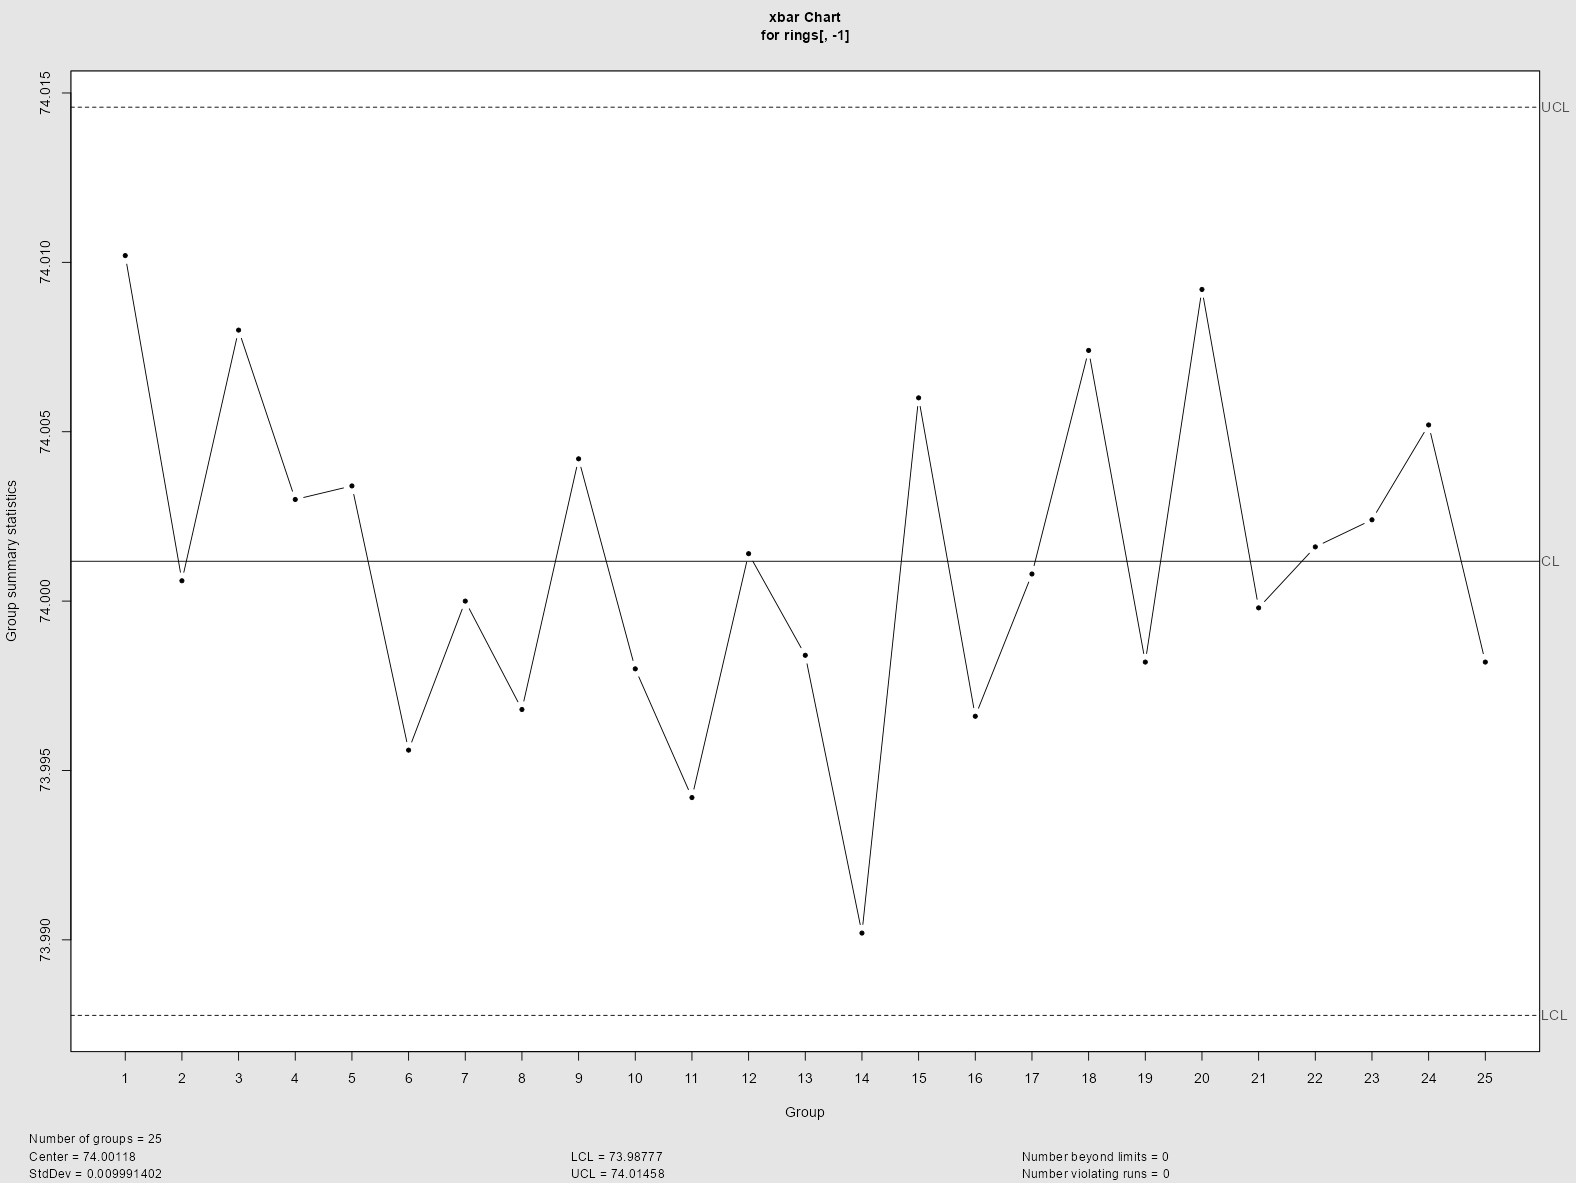

List of 11
 $ call      : language qcc(data = rings[, -1], type = "xbar", std.dev = sig_hat, plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "rings[, -1]"
 $ data      : num [1:25, 1:5] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 74 74 74 74 74 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 74
 $ std.dev   : num 0.00999
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 74 74
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [3]:
sig_hat <- sd.xbar(rings[,-1]) # This gives us s-bar/c4

qcc(rings[,-1],type="xbar",std.dev=sig_hat,plot=TRUE)


**$s$ chart:**

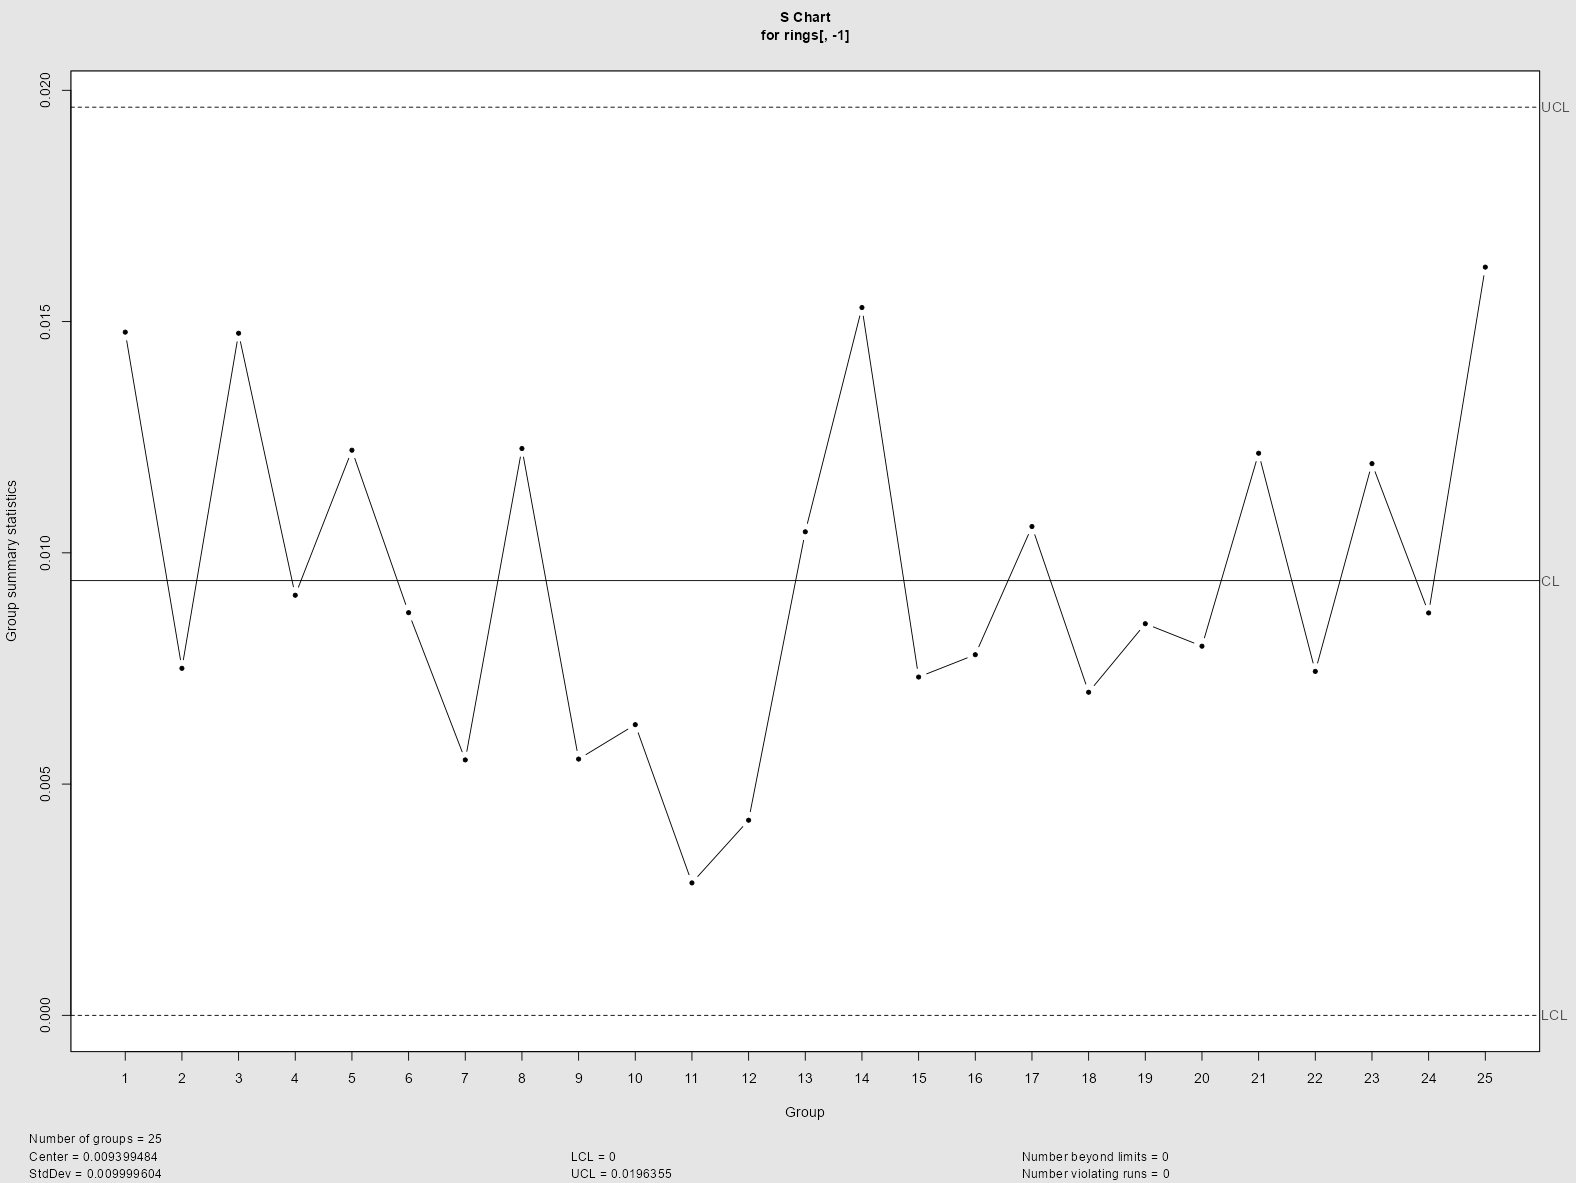

List of 11
 $ call      : language qcc(data = rings[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "rings[, -1]"
 $ data      : num [1:25, 1:5] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01477 0.0075 0.01475 0.00908 0.01222 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0094
 $ std.dev   : num 0.01
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0196
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [4]:
qcc(rings[,-1],type="S",plot=TRUE)


In both cases, we have evidence of Phase I statistical control from our historical data. We can now move into Phase II (online) monitoring:

### Phase II Monitoring

Let's use the Phase I limits and center values in Phase II using the Phase II rings data.


In [5]:
## Read in Phase II data ##

rings2 <- read_xlsx("Phase II rings data.xlsx")

## Save the Phase I limits and center values ##

## Limits ##

xbar_lims <- qcc(rings[,-1],type="xbar",std.dev=sig_hat,plot=FALSE)$limits

s_lims <- qcc(rings[,-1],type="S",plot=FALSE)$limits

## Center Values ##

xbar_center <- qcc(rings[,-1],type="xbar",std.dev=sig_hat,plot=FALSE)$center

s_center <- qcc(rings[,-1],type="S",plot=FALSE)$center


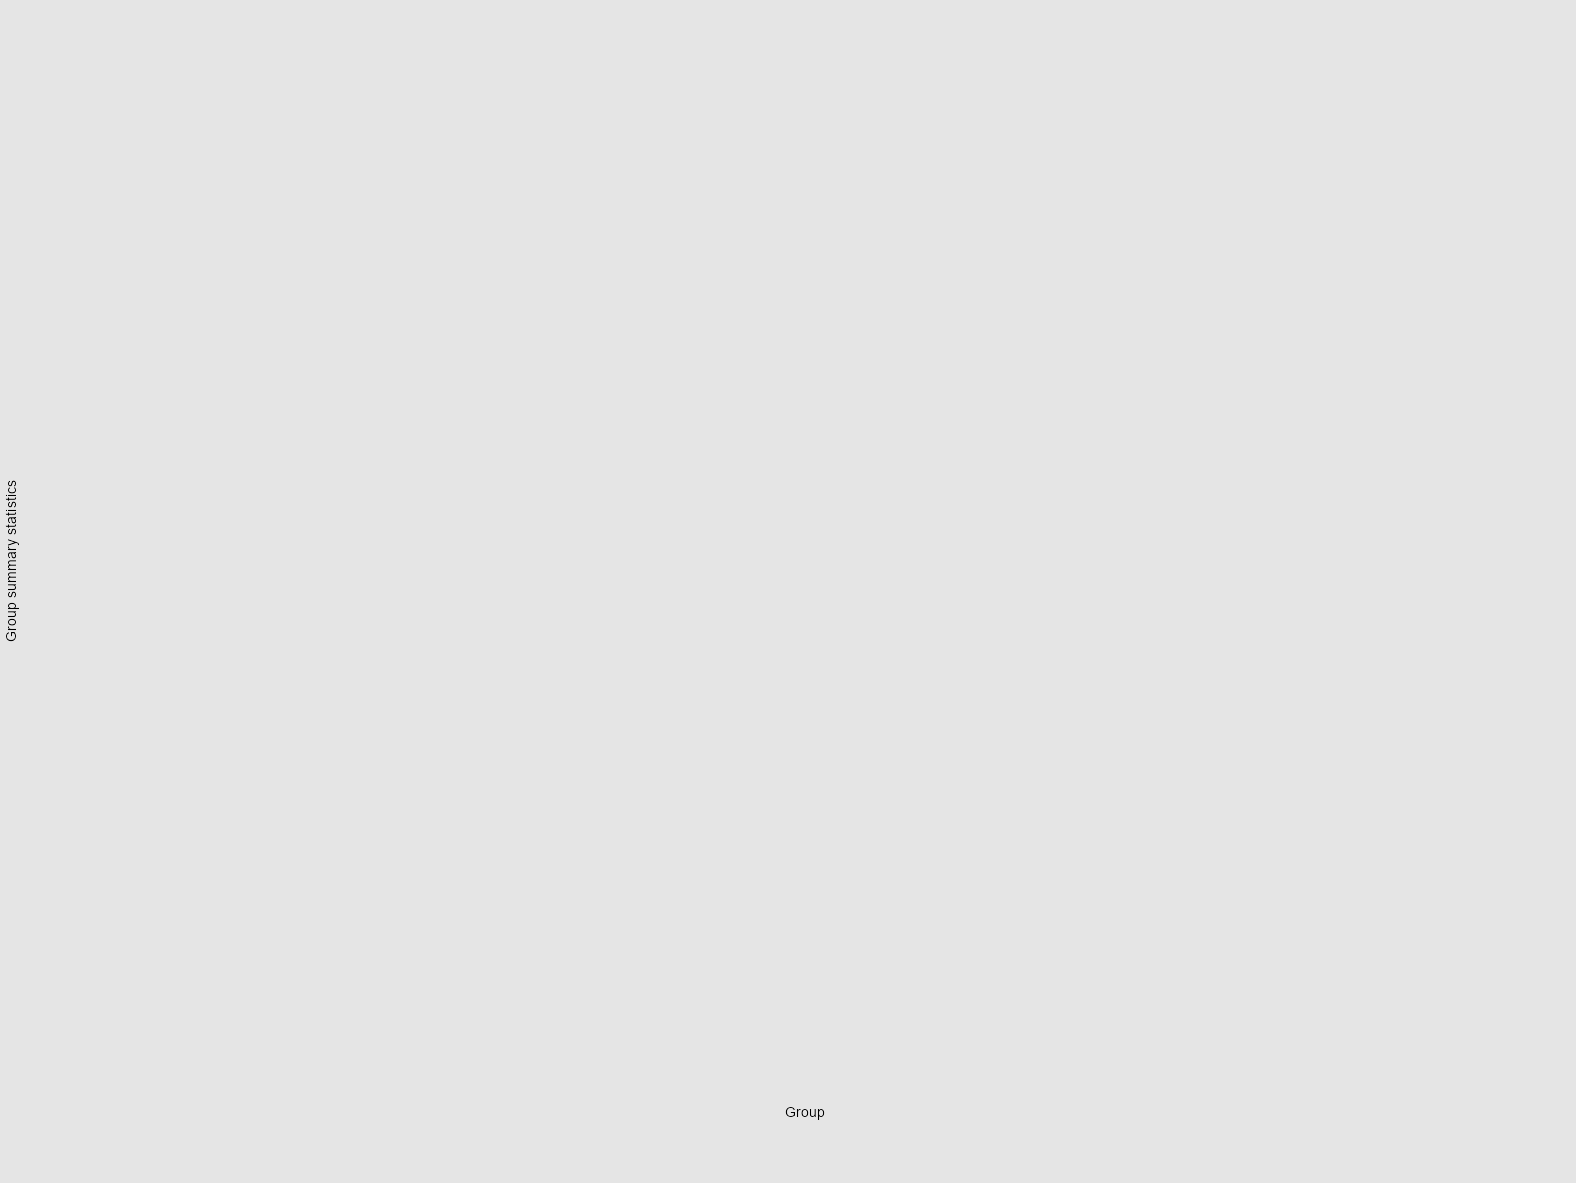

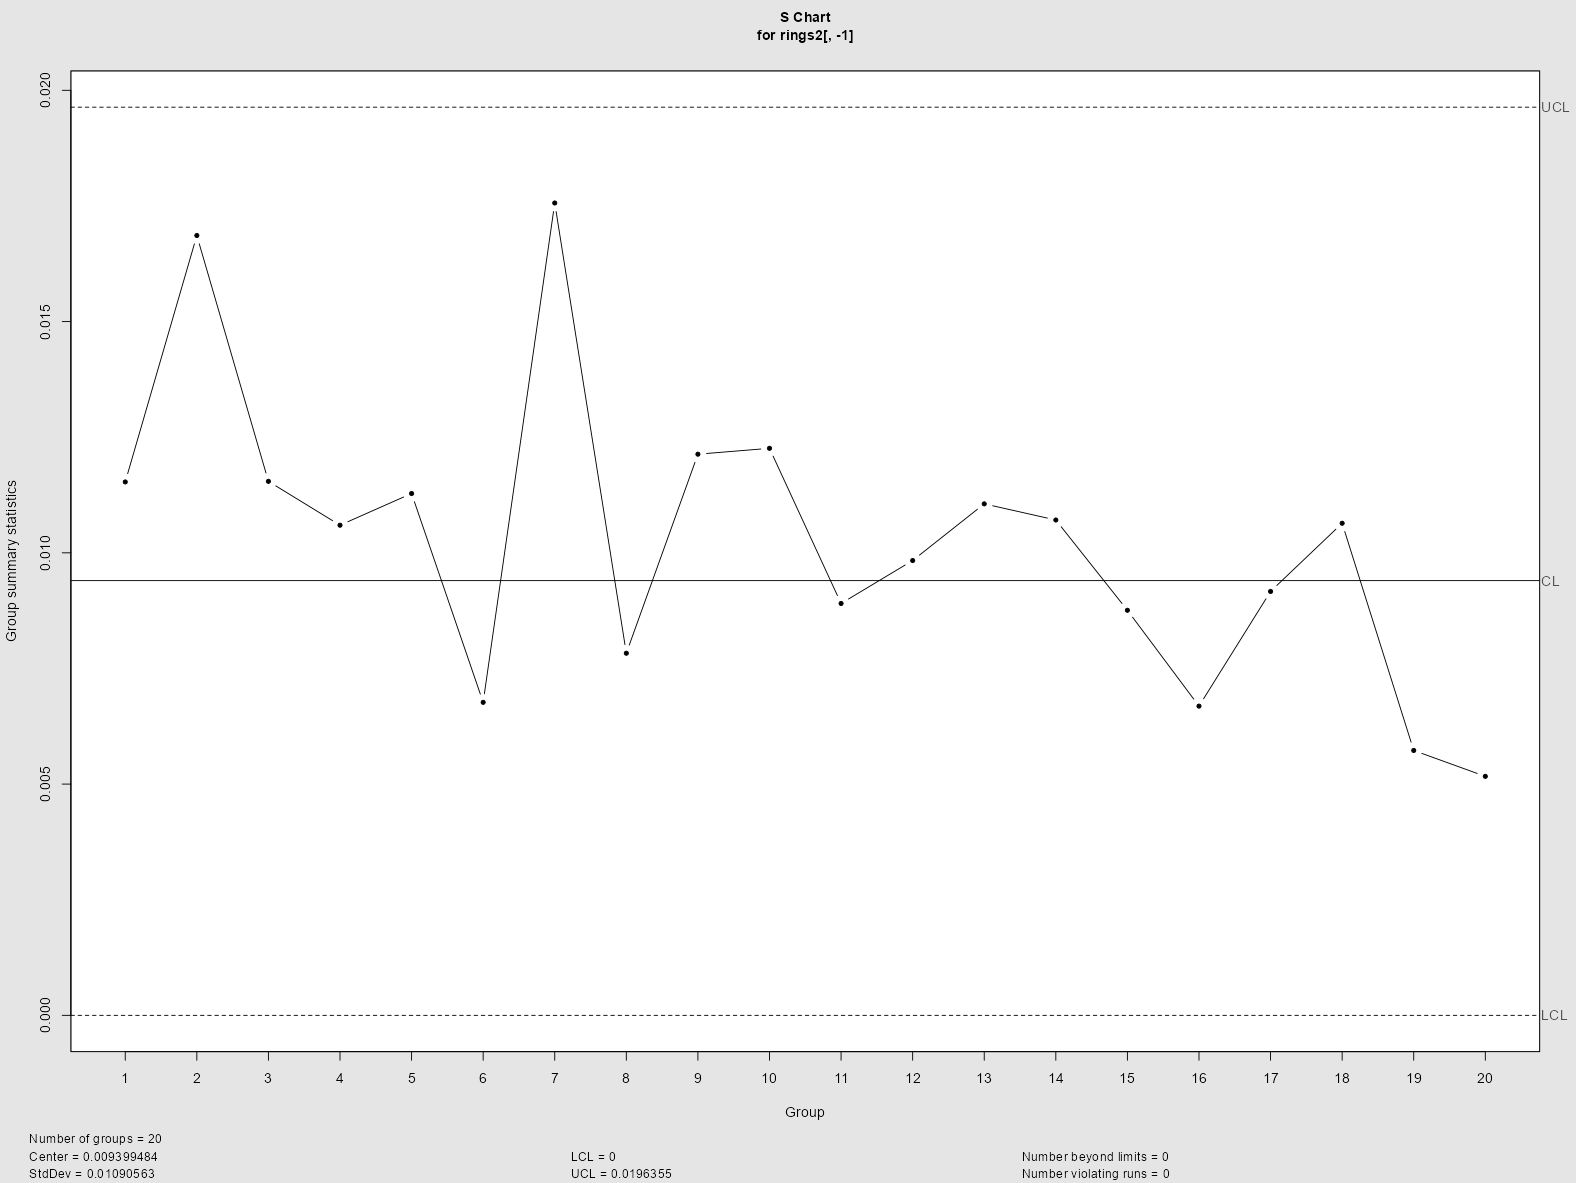

List of 11
 $ call      : language qcc(data = rings2[, -1], type = "S", center = s_center, limits = s_lims, plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "rings2[, -1]"
 $ data      : num [1:20, 1:5] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 0.0115 0.0169 0.0115 0.0106 0.0113 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0094
 $ std.dev   : num 0.0109
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0196
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [6]:
## Phase II X-bar ##

qcc(rings2[,-1],type="xbar",center=xbar_center,limits=xbar_lims,plot=TRUE)

## Phase II S ##

qcc(rings2[,-1],type="S",center=s_center,limits=s_lims,plot=TRUE)

## So we have evidence that the mean has shifted, but not the variance ##


### Variable Sample Size

As mentioned at the onset, one of the reasons to use the $s$-chart instead of the $R$-chart is in situations where our sample size varies from sample to sample.

Such a situation is likely to occur in a situation like coffee shop customer satisfaction surveys. Here, we would have to modify our estimation of both $\mu$ and $\sigma$:

$$ \hat{\mu} = \bar{\bar{x}} = \frac{\sum_{i=1}^{m}n_i\bar{x}_i}{\sum_{i=1}^{m}n_i} $$

$$ \bar{s} = \Bigg[\frac{\sum_{i=1}^{m}(n_i-1)s_i^2}{\sum_{i=1}^{m}n_i - m}\Bigg]^{1/2} $$

Now, to calculate control limits, we have to be careful because $c_4$, $D_3$, $D_4$, and $A_3$ are all dependent on sample size, and will thus change with a change in sample size.

*Note:* if the sample size doesn't vary wildly and there are lots of samples with the same number of observations, the text suggests taking the average sample standard deviation from those samples with the modal sample size, and using the standard estimate $\hat{\sigma} = \bar{s}/c_4$. However, the criteria for using this method are nebulous, and it also omits data points, which could decrease the consistency of the estimator — so we use the general formulas above instead.


In [7]:
## Phase I X-bar and s Control Charts w/Variable Sample Size ##

rings1 <- read_xlsx("Piston Rings - Variable Sample Size.xlsx")

rings1 |>
  glimpse()


Rows: 25
Columns: 6
$ Sample <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25
$ Obs1   <dbl> 74.030, 73.995, 73.988, 74.002, 73.992, 74.009, 73.995, 73.985, 74.008, 73.998, 73.994, 74.004, 73.983, 74.006, 74.012, 74.000, 73.994, 74.006, 73.984, 74.000,…
$ Obs2   <dbl> 74.002, 73.992, 74.024, 73.996, 74.007, 73.994, 74.006, 74.003, 73.995, 74.000, 73.998, 74.000, 74.002, 73.967, 74.014, 73.984, 74.012, 74.010, 74.002, 74.010,…
$ Obs3   <dbl> 74.019, 74.001, 74.021, 73.993, 74.015, 73.997, 73.994, 73.993, 74.009, 73.990, 73.994, 74.007, 73.998, 73.994, 73.998, 74.005, 73.986, 74.018, 74.003, 74.013,…
$ Obs4   <dbl> 73.992, NA, 74.005, 74.015, 73.989, 73.985, 74.000, 74.015, 74.005, 74.007, 73.995, 74.000, NA, 74.000, 73.999, 73.998, 74.005, 74.003, 74.005, NA, 74.005, 74.…
$ Obs5   <dbl> 74.008, NA, 74.002, 74.009, 74.014, NA, NA, 73.988, NA, 73.995, 73.990, 73.996, NA, 73.984, 74.007, 73.996, NA, 74.000, 73.997, NA, 73.996, 74.009, 74.014, 

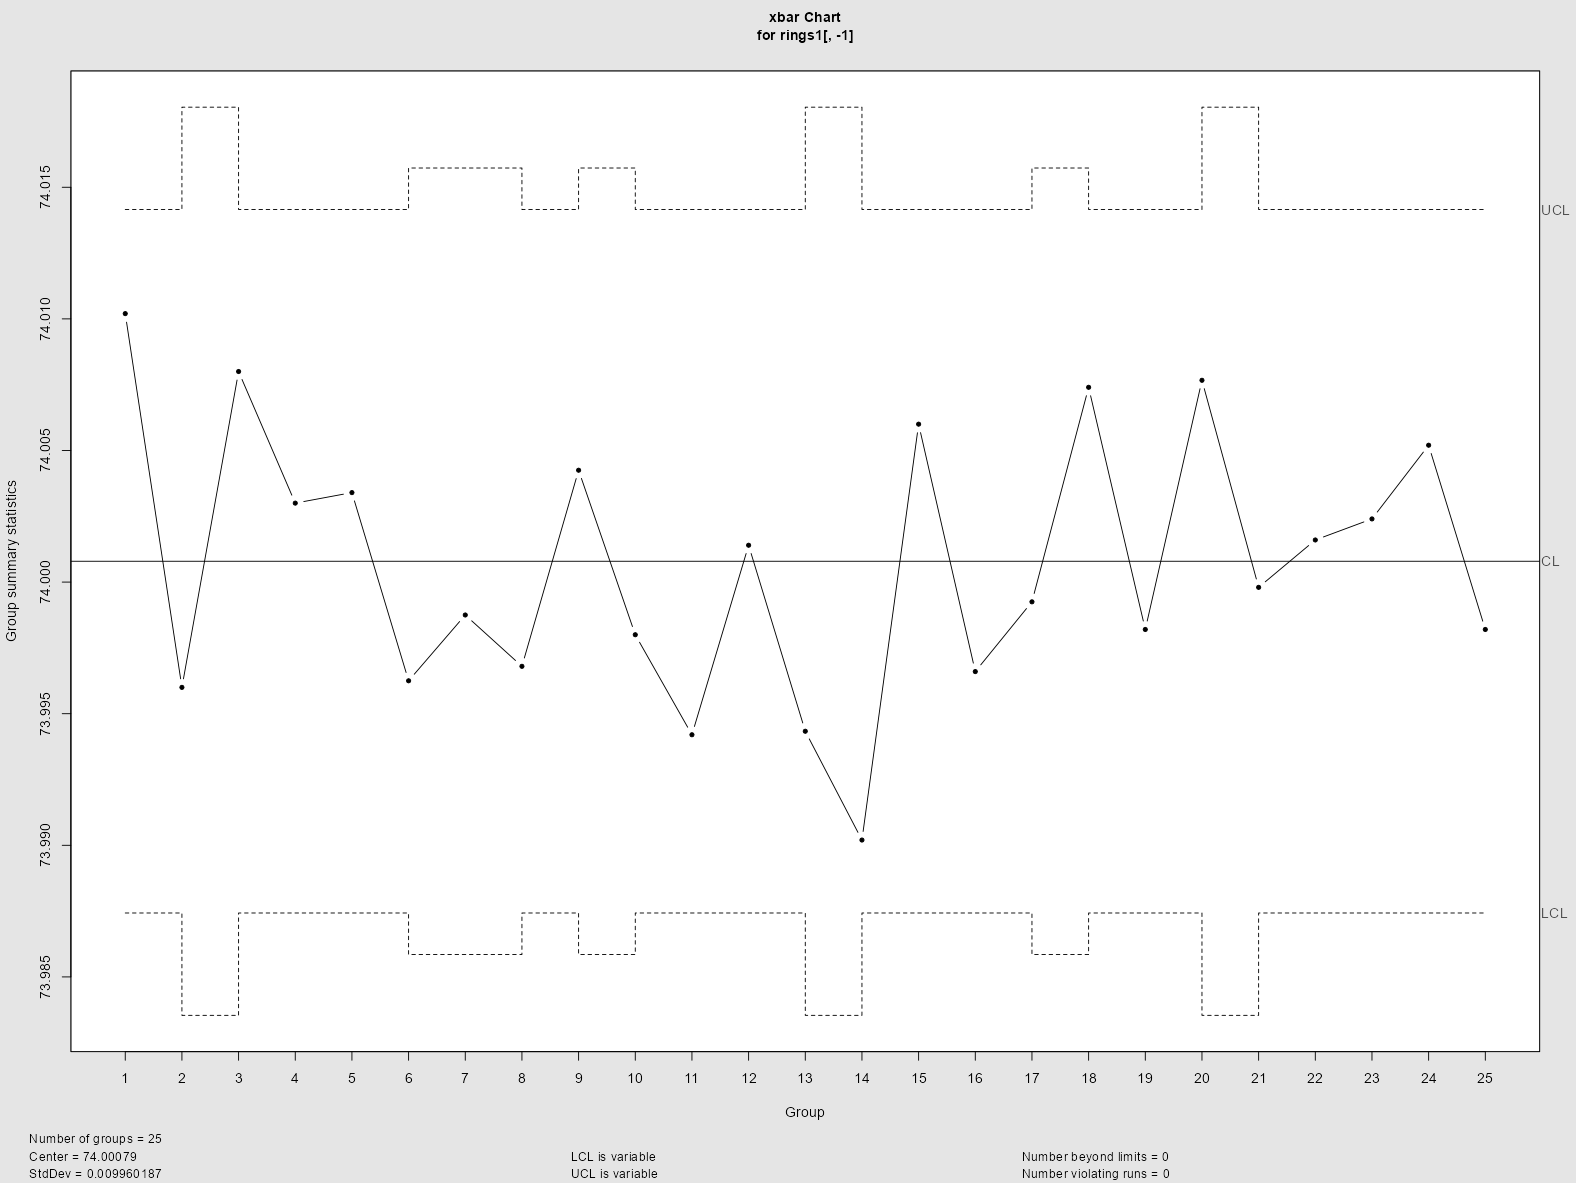

List of 11
 $ call      : language qcc(data = rings1[, -1], type = "xbar", sizes = n, center = xdbar, plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "rings1[, -1]"
 $ data      : num [1:25, 1:5] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 74 74 74 74 74 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 3 5 5 5 4 4 5 4 5 ...
 $ center    : num 74
 $ std.dev   : num 0.00996
 $ nsigmas   : num 3
 $ limits    : num [1:25, 1:2] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [8]:
## X-bar ##

numerator <- sum(

  apply(rings1[,-1],1,FUN=function(x){

  sum(!is.na(x))*mean(x,na.rm=T)

  })

)

denominator <- sum(

  apply(rings1[,-1],1,FUN=function(x){

    sum(!is.na(x))

  })

)

xdbar <- numerator/denominator

## Specify Sample Sizes ##

n <- apply(rings1[,-1],1,FUN=function(x){

  sum(!is.na(x))

})

## Estimate SD ##

## Note, RMSDF will give us the sbar from the notes ##

sbar <- sd.xbar(rings1[,-1],sizes=n,std.dev="RMSDF")

qcc(rings1[,-1],type="xbar",sizes = n,center=xdbar,plot=TRUE)


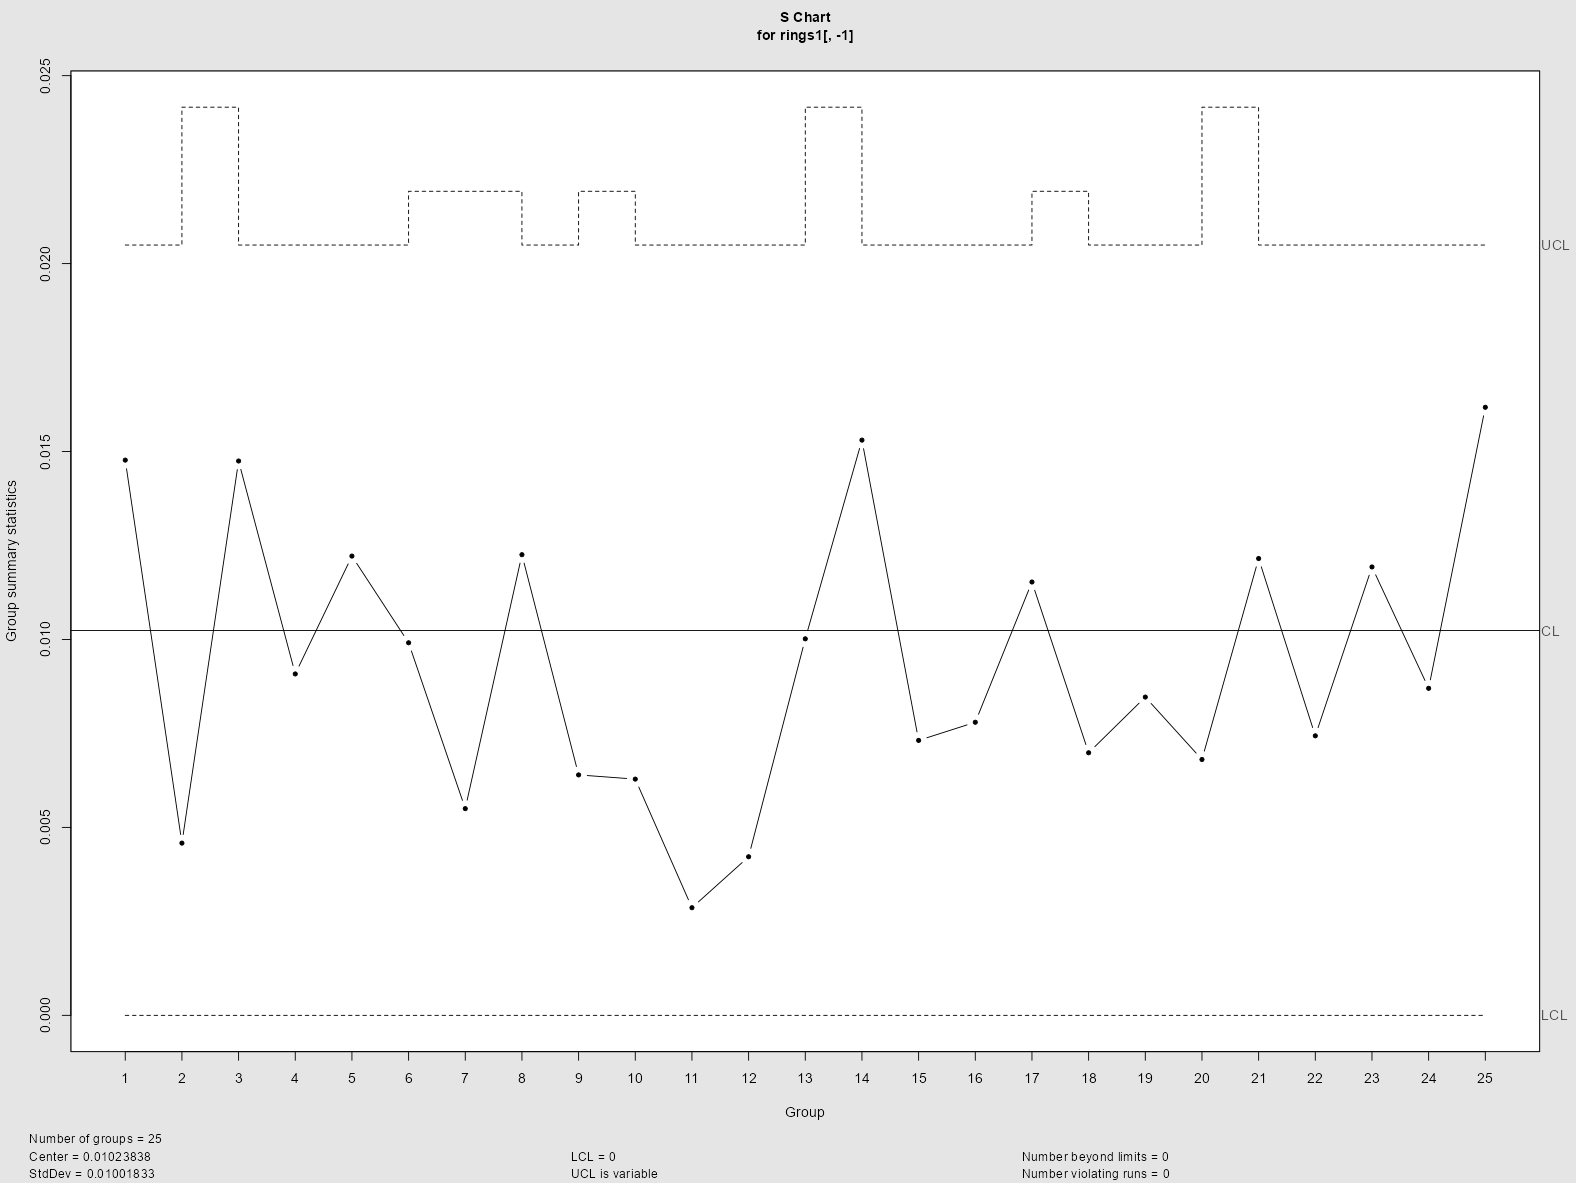

List of 11
 $ call      : language qcc(data = rings1[, -1], type = "S", center = sbar, plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "rings1[, -1]"
 $ data      : num [1:25, 1:5] 74 74 74 74 74 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01477 0.00458 0.01475 0.00908 0.01222 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 3 5 5 5 4 4 5 4 5 ...
 $ center    : num 0.0102
 $ std.dev   : num 0.01
 $ nsigmas   : num 3
 $ limits    : num [1:25, 1:2] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [9]:
## S ##

qcc(rings1[,-1],type="S",center=sbar,plot=TRUE)


<a id="s2-chart"></a>
## The $s^2$ Chart

While the $s$-chart is used quite a lot in industry, there is one reason people may potentially avoid it.

When our observations come from a normal distribution, and the size of our samples is small ($n < 10$), the sampling distribution of $s$ is asymmetric, and thus using $3\sigma$ limits yields a true $\alpha$ value that is different from the $0.0027$ we expect with such limits.

Because of this limitation, some may be inclined to use a control chart built on the *exact* statistical properties of the plotting statistic — which is where the $s^2$ chart comes into play.


### Statistical foundation

We know from prior statistics courses that (again, if the underlying observations come from a normal distribution):

$$ \frac{(n-1)s^2}{\sigma^2} \sim \chi^2(n-1) $$

Using confidence interval principles, if the process is in-control we would expect:

$$ P\bigg[\chi^2_{\alpha/2,n-1} < \frac{(n-1)s^2}{\sigma^2} < \chi^2_{1-\alpha/2,n-1}\bigg] = 1-\alpha $$

Rearranging:

$$ P\Bigg[\frac{\sigma^2\chi^2_{\alpha/2,n-1}}{n-1} < s^2 < \frac{\sigma^2\chi^2_{1-\alpha/2,n-1}}{n-1}\Bigg] = 1 - \alpha $$

If we know $\sigma^2$, we can use that directly; if we don't, we collect $m$ Phase I samples of size $n$, calculate the sample variance for each sample, and use the mean of those variances ($\bar{s}^2$) as our estimator for $\sigma^2$.

Unfortunately, there is not a built-in function in R (that we could find) that automatically generates this control chart — but we can build it manually.


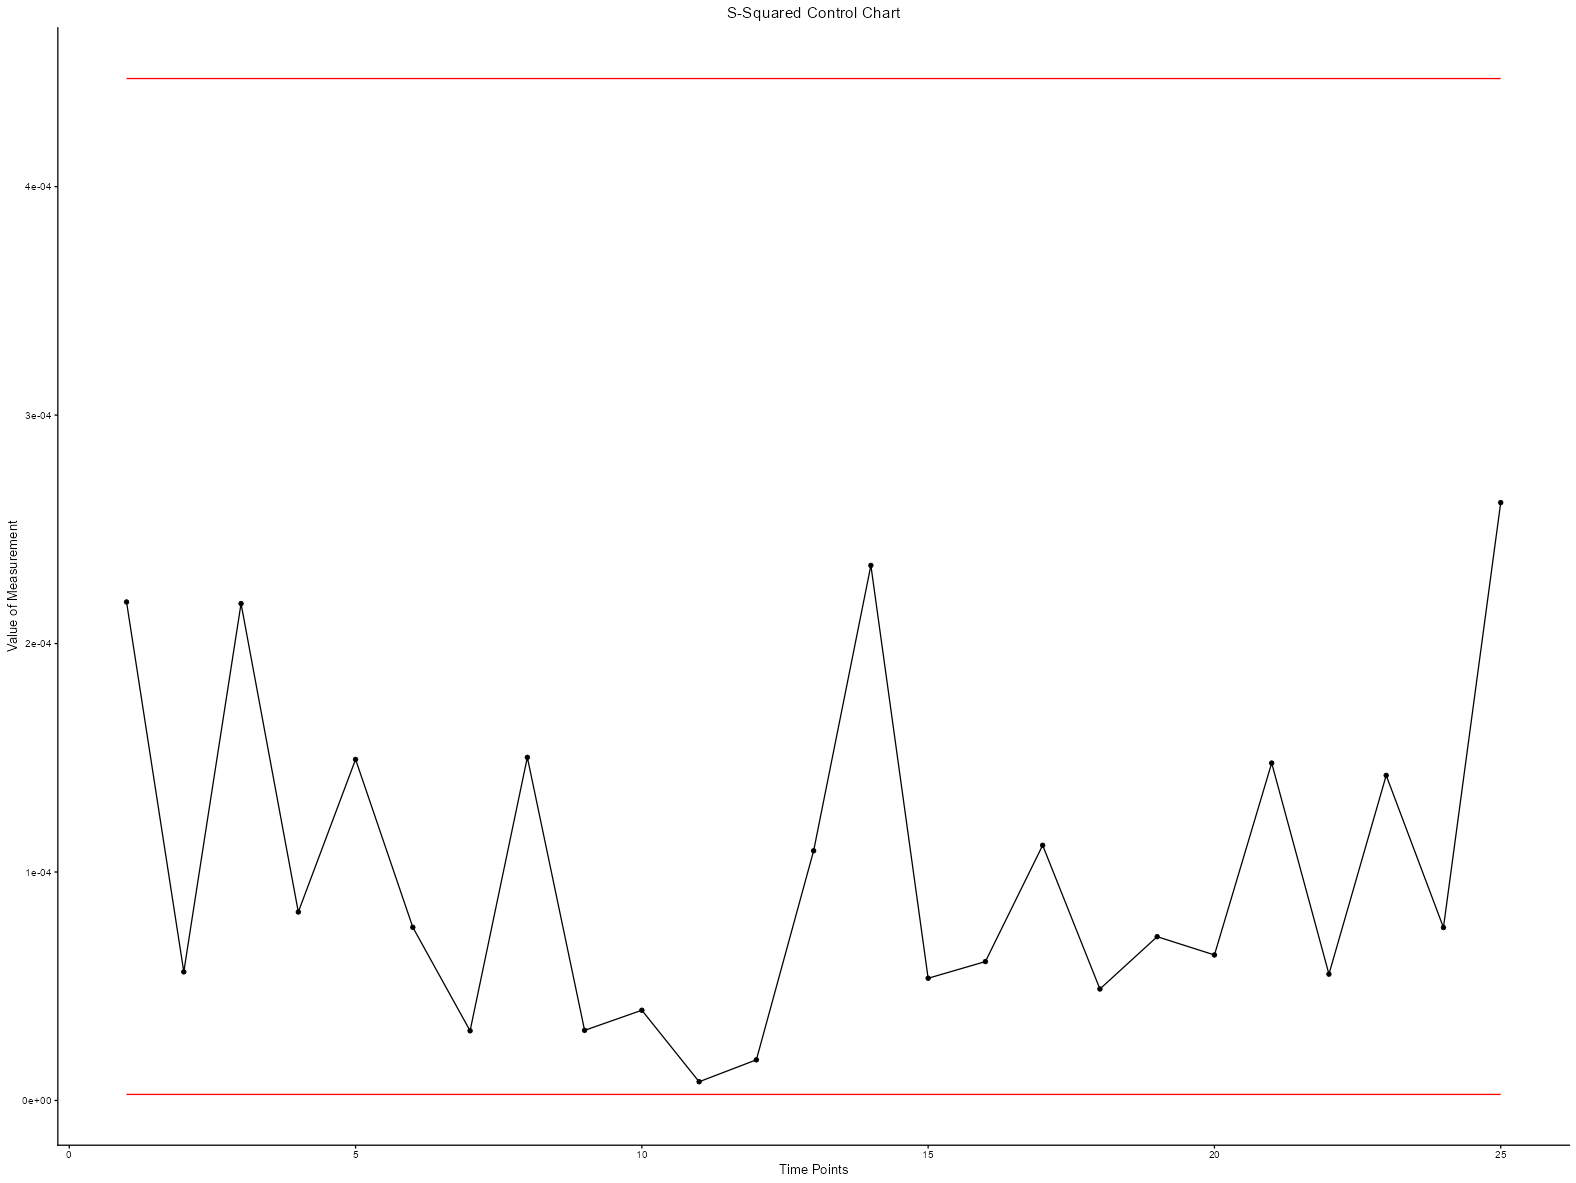

In [10]:
## Code for Generating Phase I s^2 Chart (Fixed Sample Size) ##

ssquared.p1 <- function(dat,alpha){

  sbar2 <- mean(apply(dat,1,var))
  UCL <- sbar2*qchisq(alpha/2,df=ncol(dat)-1,lower.tail=F)/(ncol(dat)-1)
  LCL <- sbar2*qchisq(alpha/2,df=ncol(dat)-1,lower.tail=T)/(ncol(dat)-1)
  s2 <- apply(dat,1,var)

  p <- ggplot() + geom_line(aes(x=seq(1,nrow(dat),by=1),y=UCL),color="red") +
                  geom_line(aes(x=seq(1,nrow(dat),by=1),y=LCL),color="red") +
                  geom_line(aes(x=seq(1,nrow(dat),by=1),y=s2),color="black") +
                  geom_point(aes(x=seq(1,nrow(dat),by=1),y=s2),color="black") +
                  labs(x="Time Points",y="Value of Measurement") +
                  theme_classic() +
                  ggtitle("S-Squared Control Chart") +
    theme(plot.title=element_text(hjust=0.5))

  print(p)

}

ssquared.p1(rings[,-1],alpha=0.0027)


## Control Charts for Individual Measurements

In practice, there are lots of instances where your sample size may be $n=1$.

- In service industries, we may rather analyze customer satisfaction or time-to-service at the individual level rather than in aggregate.
- We may also encounter this situation in fast-paced manufacturing environments where observations are automatically performed for each unit produced.


In these situations, where the sample size is $n=1$ **and** the magnitude of a shift away from target is relatively large (i.e., $>2\sigma$), the text suggests using the **Control Chart for Individual Measurements (CCIM)** along with a **Moving Range (MR) Chart**.

The plotting statistic for the CCIM is simply a single observed value. For the MR chart, we define the plotting statistic as:

$$ MR_i = |x_i - x_{i-1}| $$


### Control limits

The control limits for the CCIM are:

$$UCL = \bar{x} + \frac{3\bar{MR}}{d_2} \qquad LCL = \bar{x} - \frac{3\bar{MR}}{d_2} $$

Here, the sample size we use for $d_2$ is $n=2$.

The control limits for the MR chart are:

$$UCL = D_4\bar{MR} \qquad LCL = D_3\bar{MR}$$

Let's look at an example of how to generate these charts in R, using the **Mortgage Loan Processing Costs** dataset.


Rows: 20
Columns: 2
$ Week <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20
$ Cost <dbl> 310, 288, 297, 298, 307, 303, 294, 297, 308, 306, 294, 299, 297, 299, 314, 295, 293, 306, 301, 304


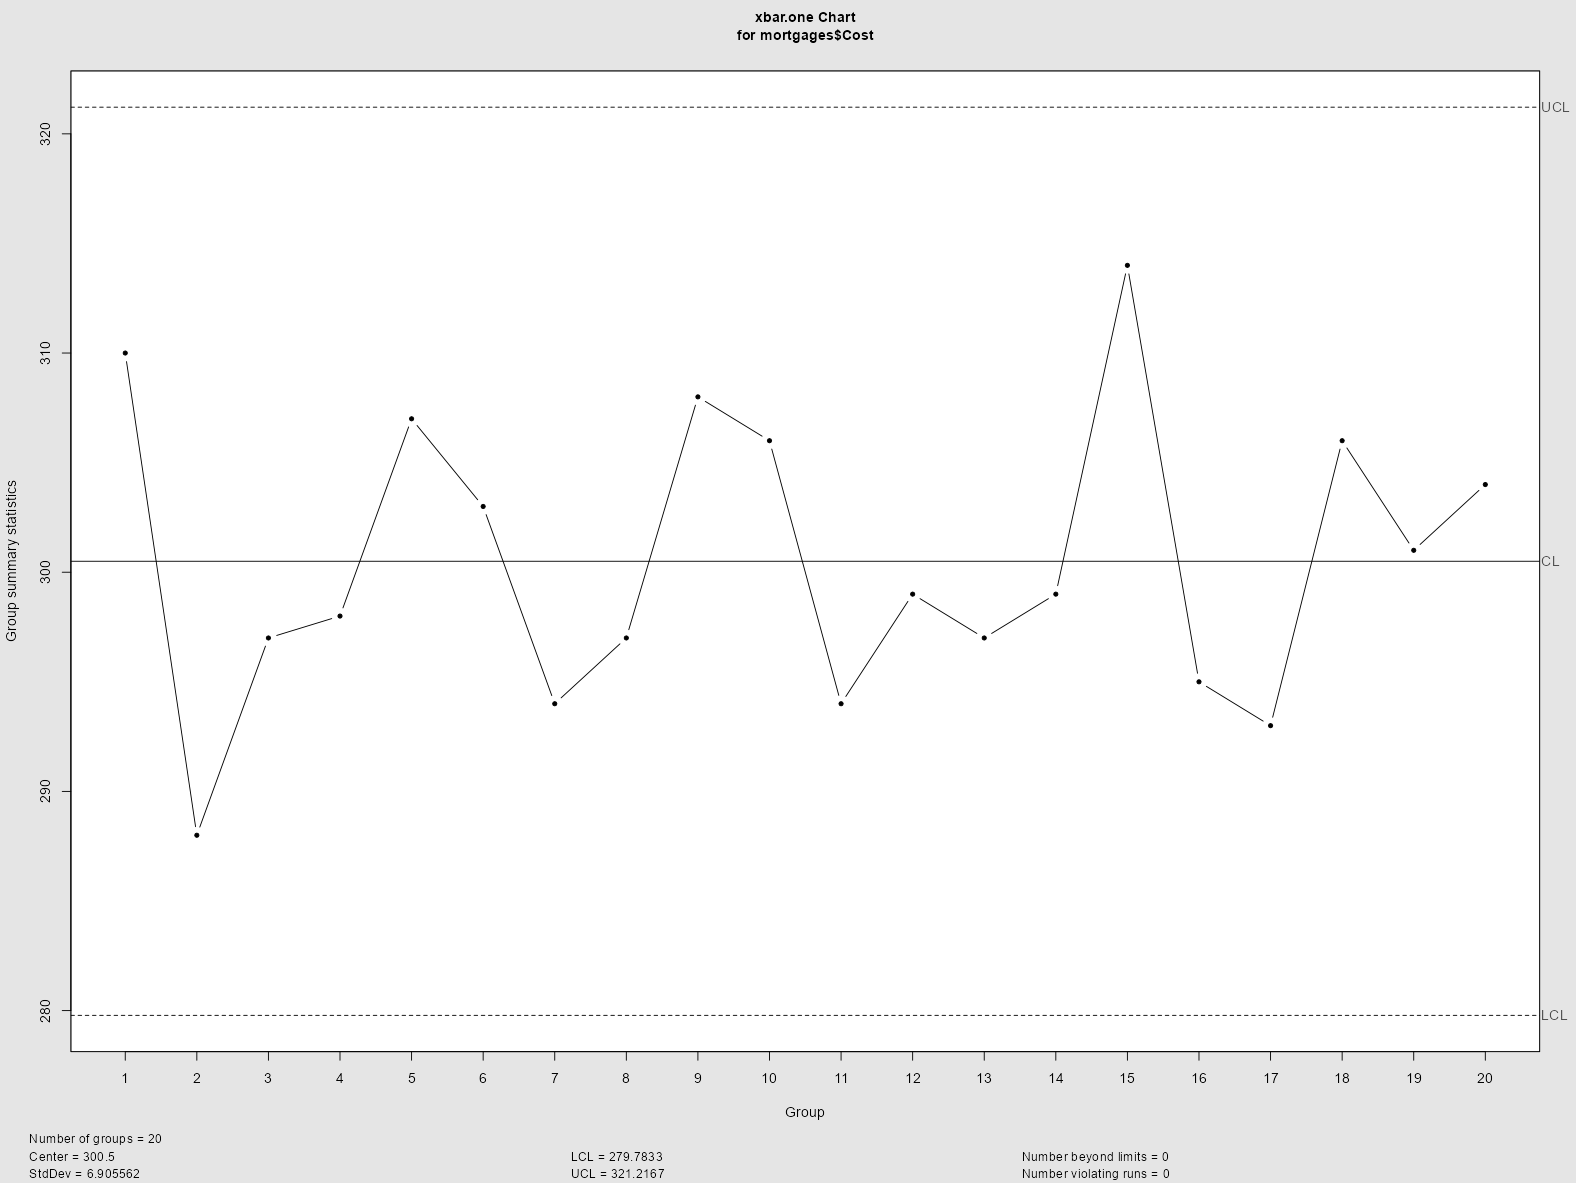

List of 11
 $ call      : language qcc(data = mortgages$Cost, type = "xbar.one", plot = TRUE)
 $ type      : chr "xbar.one"
 $ data.name : chr "mortgages$Cost"
 $ data      : num [1:20, 1] 310 288 297 298 307 303 294 297 308 306 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 310 288 297 298 307 303 294 297 308 306 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 1 1 1 1 1 1 1 1 1 1 ...
 $ center    : num 300
 $ std.dev   : num 6.91
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 280 321
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [11]:
## Control Charts for Individuals ##

mortgages <- read_xlsx("Mortgage Loan Costs.xlsx")

mortgages |>
  glimpse()

qcc(mortgages$Cost,type="xbar.one",plot=TRUE)


Rows: 20
Columns: 3
$ Week <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20
$ Cost <dbl> 310, 288, 297, 298, 307, 303, 294, 297, 308, 306, 294, 299, 297, 299, 314, 295, 293, 306, 301, 304
$ MR   <dbl> NA, 22, 9, 1, 9, 4, 9, 3, 11, 2, 12, 5, 2, 2, 15, 19, 2, 13, 5, 3


Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_point()`). 


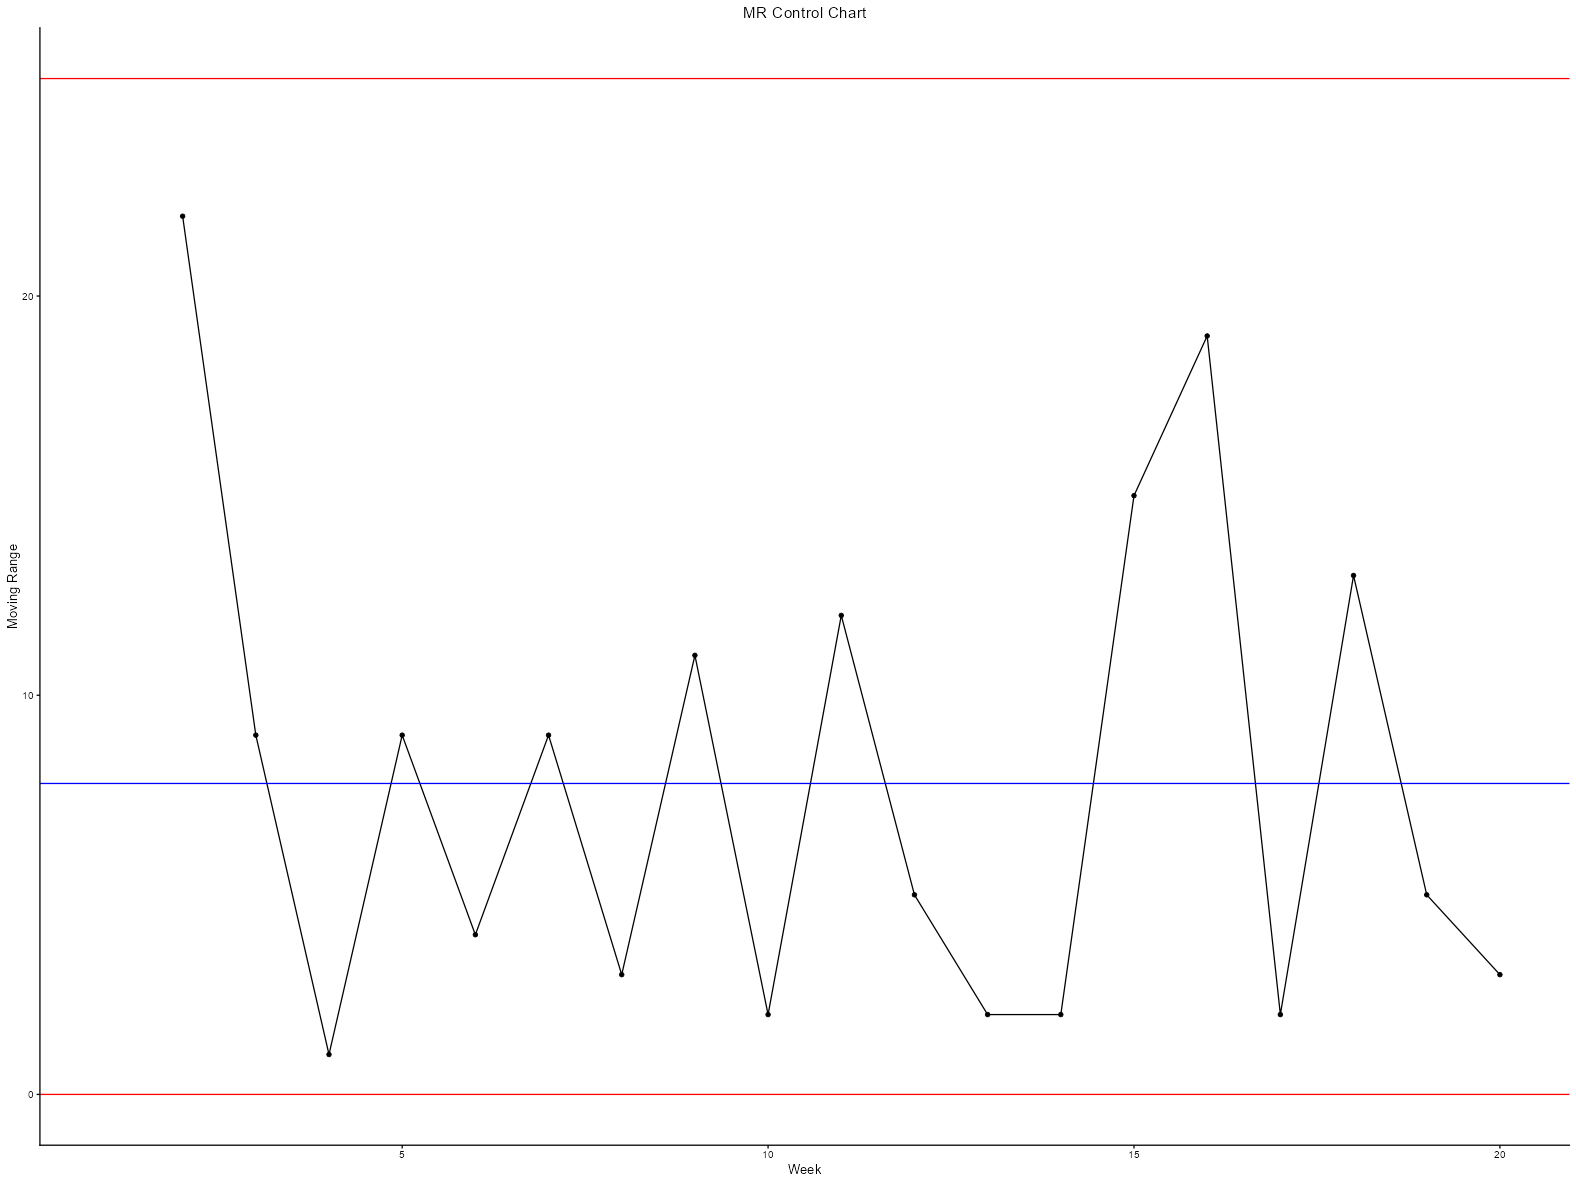

In [12]:
## Control Chart for Moving Range ##

mortgages <- mortgages |>
  mutate(MR = c(NA,abs(diff(Cost))))

mortgages |>
  glimpse()

MR_bar <- mean(mortgages$MR,na.rm=T)
D3 <- 0 #D3 for n=2
D4 <- 3.267 #D4 for n=2

UCL_MR <- D4*MR_bar
LCL_MR <- D3*MR_bar

## Plot MR Control Chart ##

mortgages |>
  ggplot(aes(x=Week,y=MR)) +
  geom_line() +
  geom_point() +
  geom_hline(yintercept=UCL_MR,color="red") +
  geom_hline(yintercept=LCL_MR,color="red") +
  geom_hline(yintercept=MR_bar,color="blue") +
  labs(x="Week",y="Moving Range",title="MR Control Chart") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.5))


### Interpreting the CCIM and MR Chart

There are a couple of things to be mindful of when interpreting the CCIM and MR charts, with specific respect to the latter.

- The MR at a current time point is a function of the MR at the previous time point, thus implying autocorrelation is inherently present.
- Resultingly, patterns are likely to show up on the chart that really aren't indicative of a change in process variability at all. In fact, some argue that the MR chart isn't really all that useful because of this.
- Additionally, the MR chart, like the $R$-chart, isn't really all that efficient at measuring changes in process variability because it's really measuring changes in mean level.


With regards to the CCIM, it can be shown that:

| Size of Shift | $\beta$ | $ARL_1$ |
|---|---|---|
| $1\sigma$ | 0.9772 | 43.96 |
| $2\sigma$ | 0.8413 | 6.30 |
| $3\sigma$ | 0.5000 | 2.00 |

This means the CCIM is highly inefficient at detecting small shifts.

Moreover, the CCIM is highly sensitive to non-normality (we don't have the benefit of the CLT with individual observations). In fact, the in-control ARL can be deteriorated by over half in the presence of heavy-tailed data, such as that which comes from a $t$-distribution with few degrees of freedom.


<a id="capability"></a>
## Deeper Dive into Process Capability

Remember from last week: process capability analysis is a set of procedures/statistical tools we use to measure process variability and compare it to technical process specifications.

This is commonly discussed in terms of manufacturing processes, but as we've seen, it can be applied to non-manufacturing processes too.

We've seen how we can use the $C_p$ index to measure process capability, as well as how we can use the humble histogram to compare process variability to technical specifications.


## $C_{pk}$ and $C_{pm}$

However, there are other indices we can use to measure process capability.

With the $C_p$ index, we assume the process is centered on the target value — that is, the process mean lies directly between the upper and lower specification limits. This also implies we're assuming $\bar{\bar{x}}$ is equal to the target value set by specification.

This might not always be reasonable!


### Example: USB stick width

Suppose we are manufacturing USB sticks. The target value for their width is 0.5 mm, the USL is 0.55 mm, and the LSL is 0.45 mm.

The process is considered "centered" if our estimate for $\bar{\bar{x}} \approx 0.5$ mm. If not, the process is considered "off-center". Let's take a look at how this might appear in a histogram.


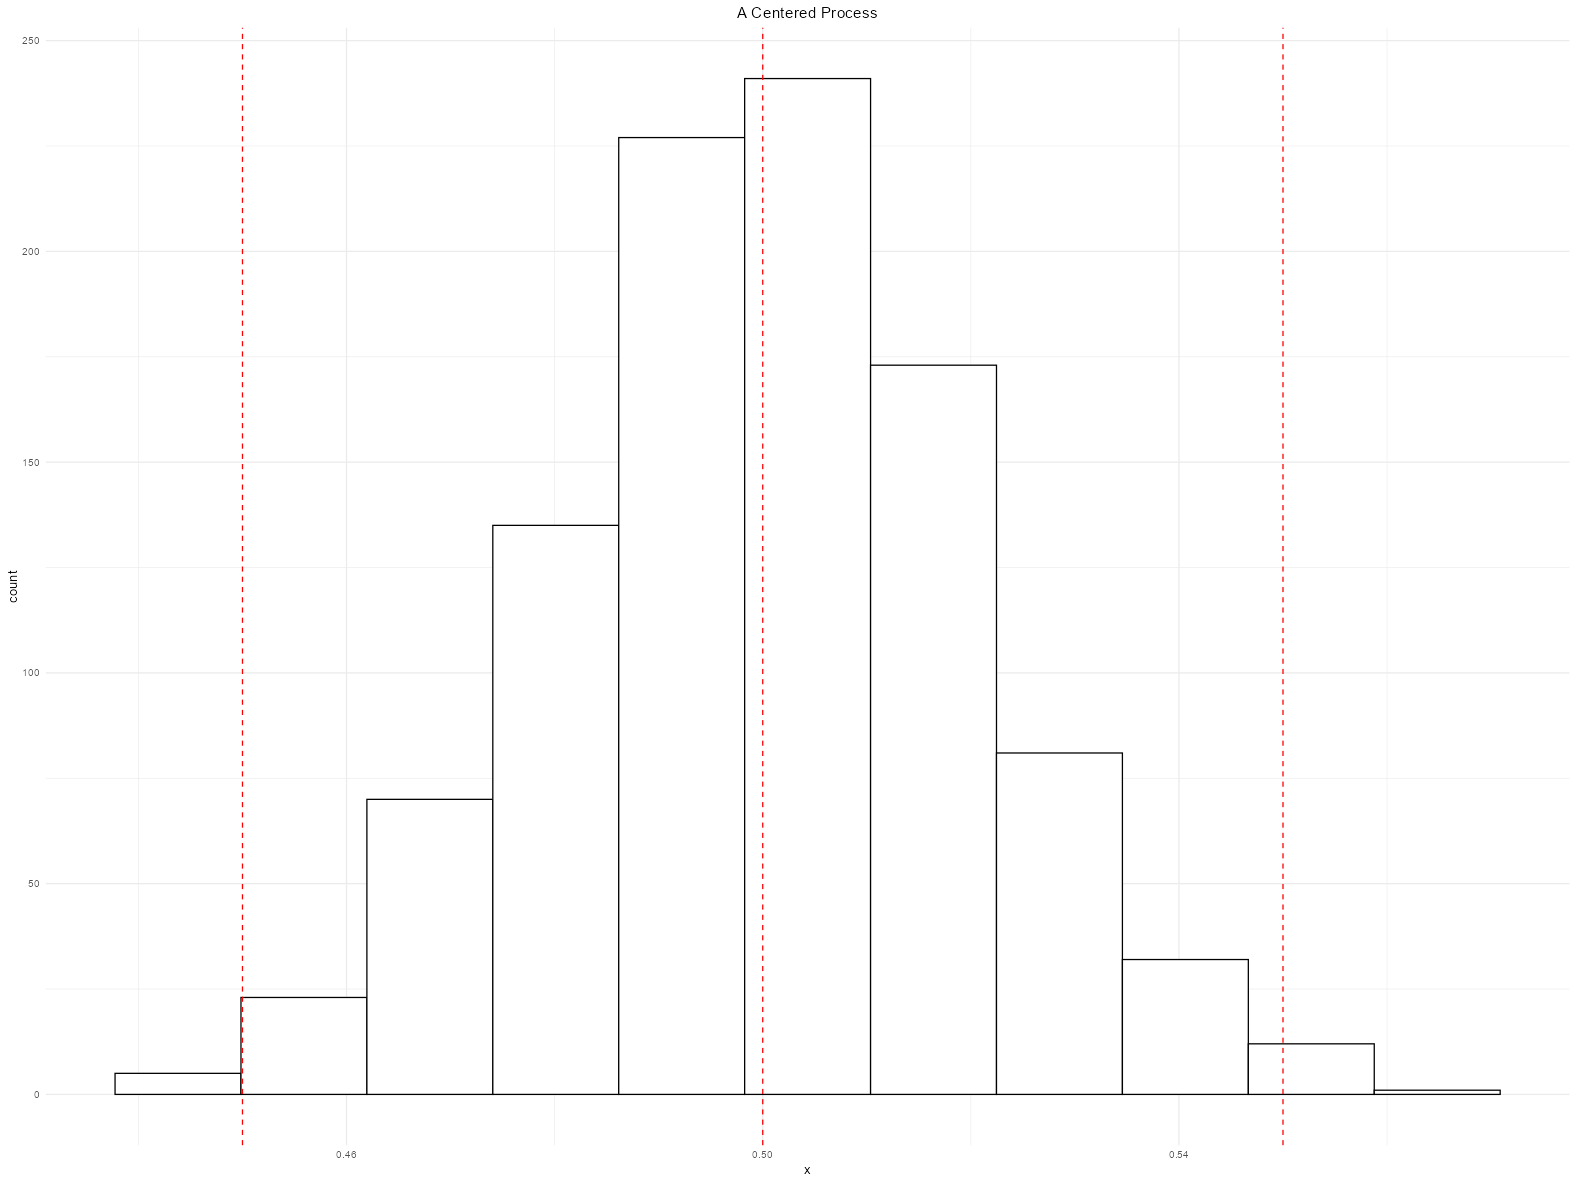

In [13]:
## Example of a Centered Process ##

set.seed(123)
n <- 1000
x <- rnorm(n,mean=0.5,sd=0.02)

ggplot(data.frame(x=x),aes(x=x)) +
  geom_histogram(bins=nclass.Sturges(x),fill="white",color="black") +
  geom_vline(xintercept=0.5,color="red",linetype="dashed") +
  geom_vline(xintercept=0.45,color='red',linetype='dashed') +
  geom_vline(xintercept=0.55,color='red',linetype='dashed') +
  labs(title="A Centered Process") +
  theme_minimal() +
  theme(plot.title=element_text(hjust=0.5))


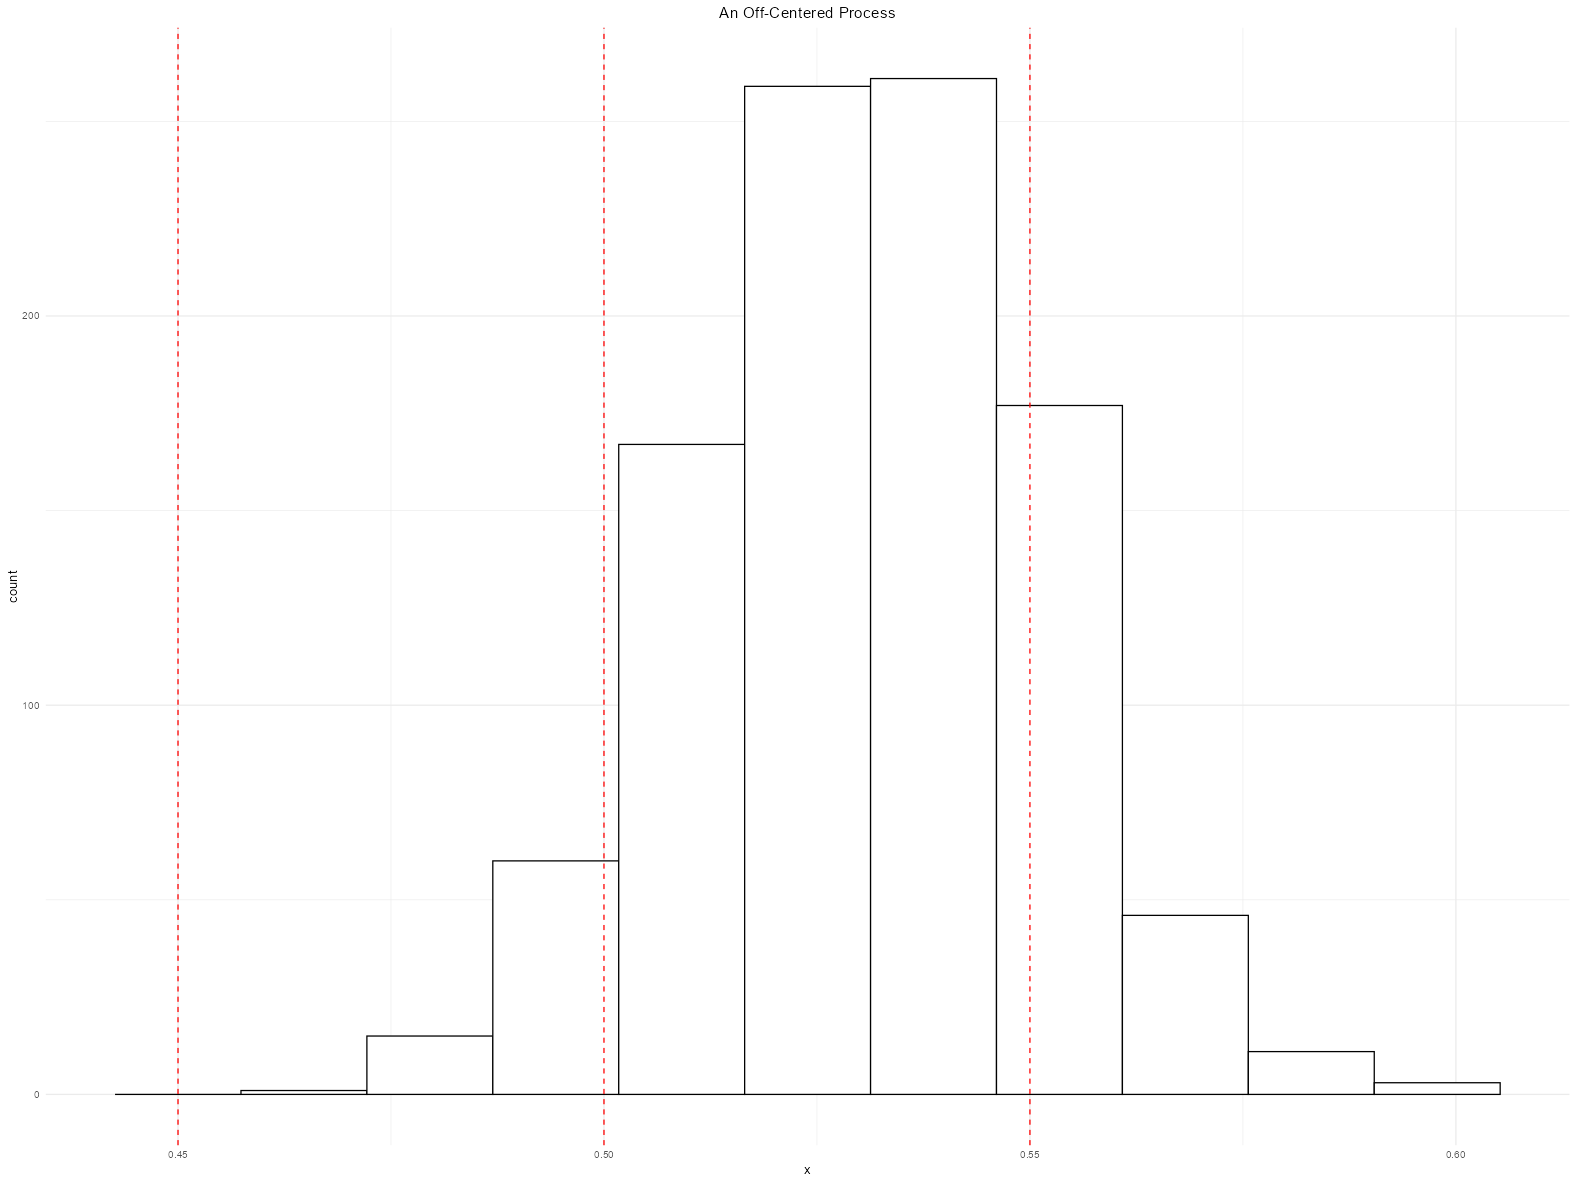

In [14]:
## Example of an Off-Centered Process ##

n <- 1000
x <- rnorm(n,mean=0.53,sd=0.02)
ggplot(data.frame(x=x),aes(x=x)) +
  geom_histogram(bins=nclass.Sturges(x),fill="white",color="black") +
  geom_vline(xintercept=0.5,color="red",linetype="dashed") +
  geom_vline(xintercept=0.45,color='red',linetype='dashed') +
  geom_vline(xintercept=0.55,color='red',linetype='dashed') +
  labs(title="An Off-Centered Process") +
  theme_minimal() +
  theme(plot.title=element_text(hjust=0.5))


As we can see, if we incorrectly assume that the process is centered, we may greatly overestimate the process's capability.

How do we address this problem? One way is to use the $C_{pk}$ index, first introduced by KSU's own professor emeritus **Dr. Victor Kane** in 1986 (article [here](https://www.tandfonline.com/doi/abs/10.1080/00224065.1986.11978984))

$$ \hat{C}_{pk} = \text{min}\Bigg[\frac{USL - \bar{\bar{x}}}{3s},\frac{\bar{\bar{x}} - LSL}{3s}\Bigg] $$

This measure is interpreted in a manner very similar to the $C_p$ index:
- If $\hat{C}_{pk} > 1$, the process is considered capable.
- If $\hat{C}_{pk} < 1$, the process is considered incapable.

The $C_{pk}$ index measures how well the process is centered on the target value by focusing on which of the two specification limits is closer to the process mean.


### Example: Battery voltage

Suppose we are manufacturing a new type of battery. The target value for the battery's voltage is 1.5 volts, the USL is 1.6 volts, and the LSL is 1.4 volts.

The Phase I data for the battery's voltage is in "Battery Voltage Phase I Data.xlsx". Let's first determine if the process is in statistical control. Then, let's calculate the $\hat{C}_p$, the FNC, and the $\hat{C}_{pk}$ indices for the battery's voltage.


In [15]:
## Read in Battery Voltage Phase I Data ##

battery <- read_xlsx("Battery Voltage Phase I Data.xlsx")

battery |>
  glimpse()


Rows: 100
Columns: 6
$ Sample <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, …
$ V1     <dbl> 1.5164, 1.5415, 1.5159, 1.5193, 1.5455, 1.5205, 1.5295, 1.5504, 1.5059, 1.5619, 1.5708, 1.5423, 1.5384, 1.5201, 1.5398, 1.5200, 1.5358, 1.5163, 1.5458, 1.5438,…
$ V2     <dbl> 1.5625, 1.5116, 1.5060, 1.5477, 1.4997, 1.5684, 1.5414, 1.4957, 1.5371, 1.5321, 1.4806, 1.5292, 1.5183, 1.5123, 1.5348, 1.5470, 1.5645, 1.4773, 1.5449, 1.5110,…
$ V3     <dbl> 1.4899, 1.5259, 1.4970, 1.5297, 1.5121, 1.5309, 1.5392, 1.5199, 1.5096, 1.5178, 1.5167, 1.5001, 1.5144, 1.5261, 1.5256, 1.5366, 1.5558, 1.5367, 1.5595, 1.5170,…
$ V4     <dbl> 1.5363, 1.5080, 1.5014, 1.5678, 1.5380, 1.5221, 1.5244, 1.5457, 1.5258, 1.5338, 1.5247, 1.5200, 1.5420, 1.5328, 1.5560, 1.5075, 1.5273, 1.5258, 1.5085, 1.5500,…
$ V5     <dbl> 1.4981, 1.4911, 1.5521, 1.5361, 1.5274, 1.5241, 1.5617, 1.5540, 1.5099, 1.5022, 1.55

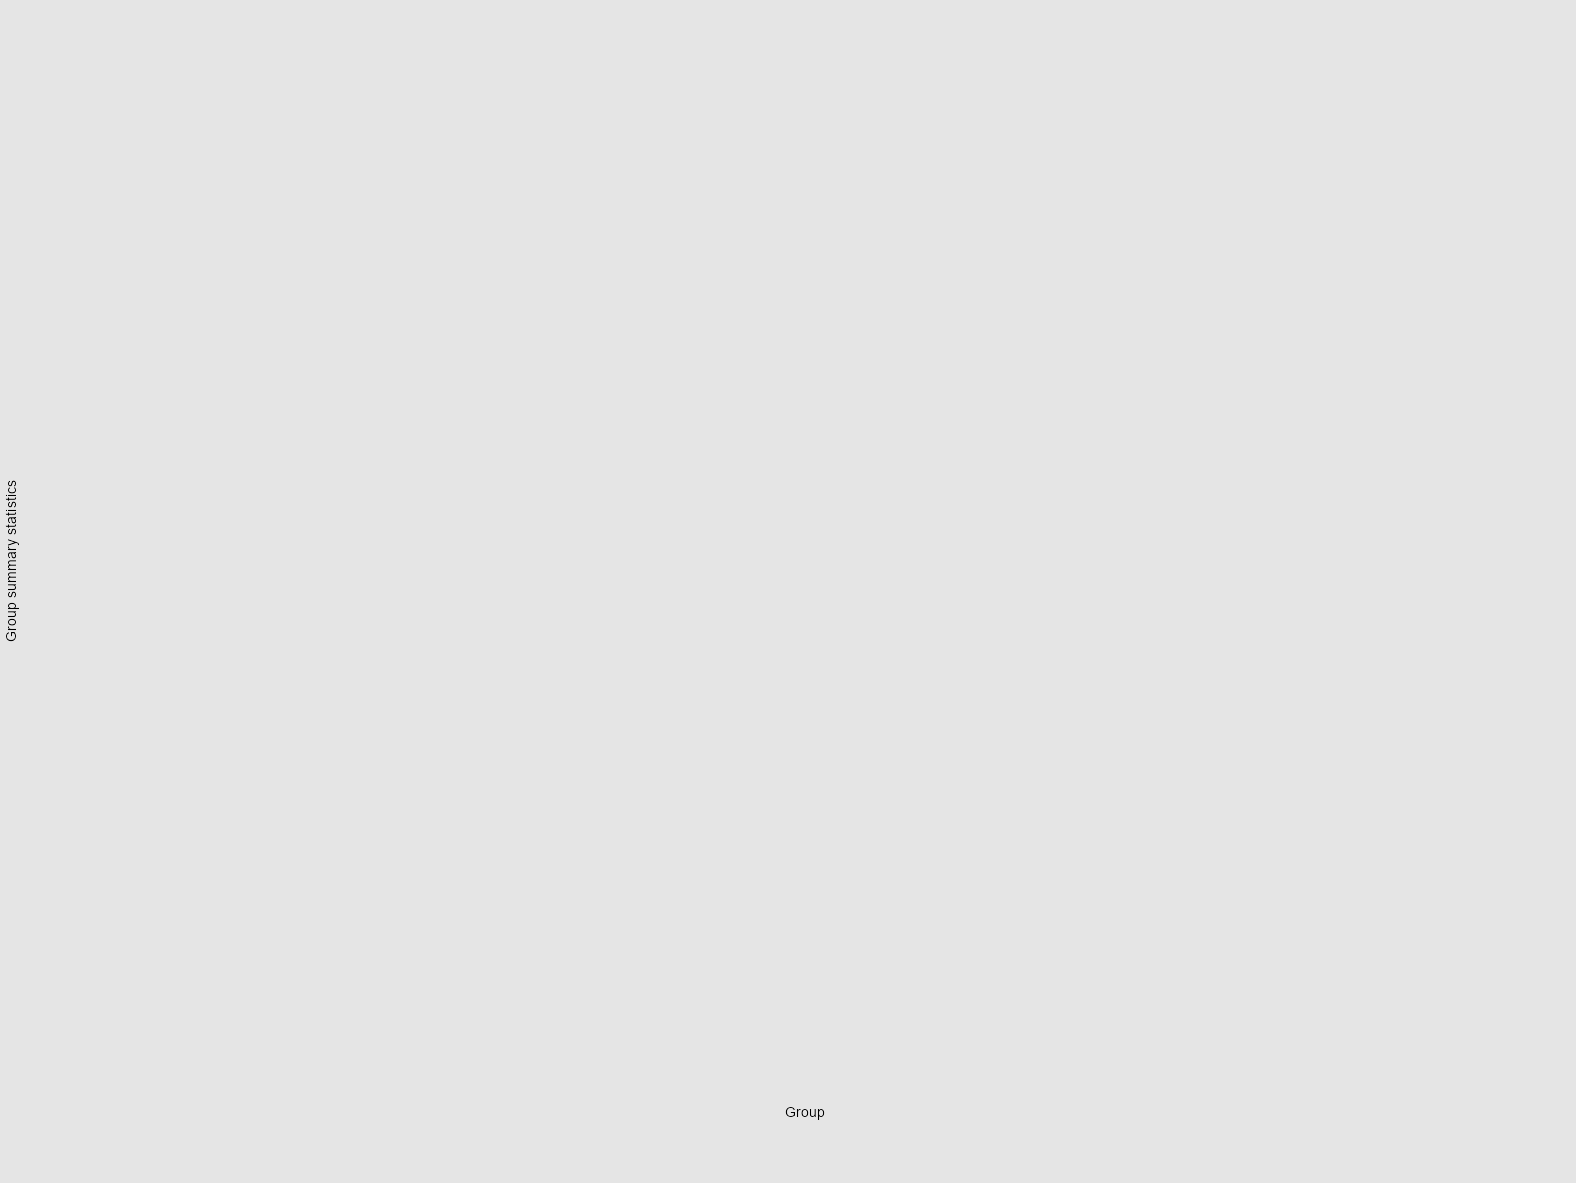

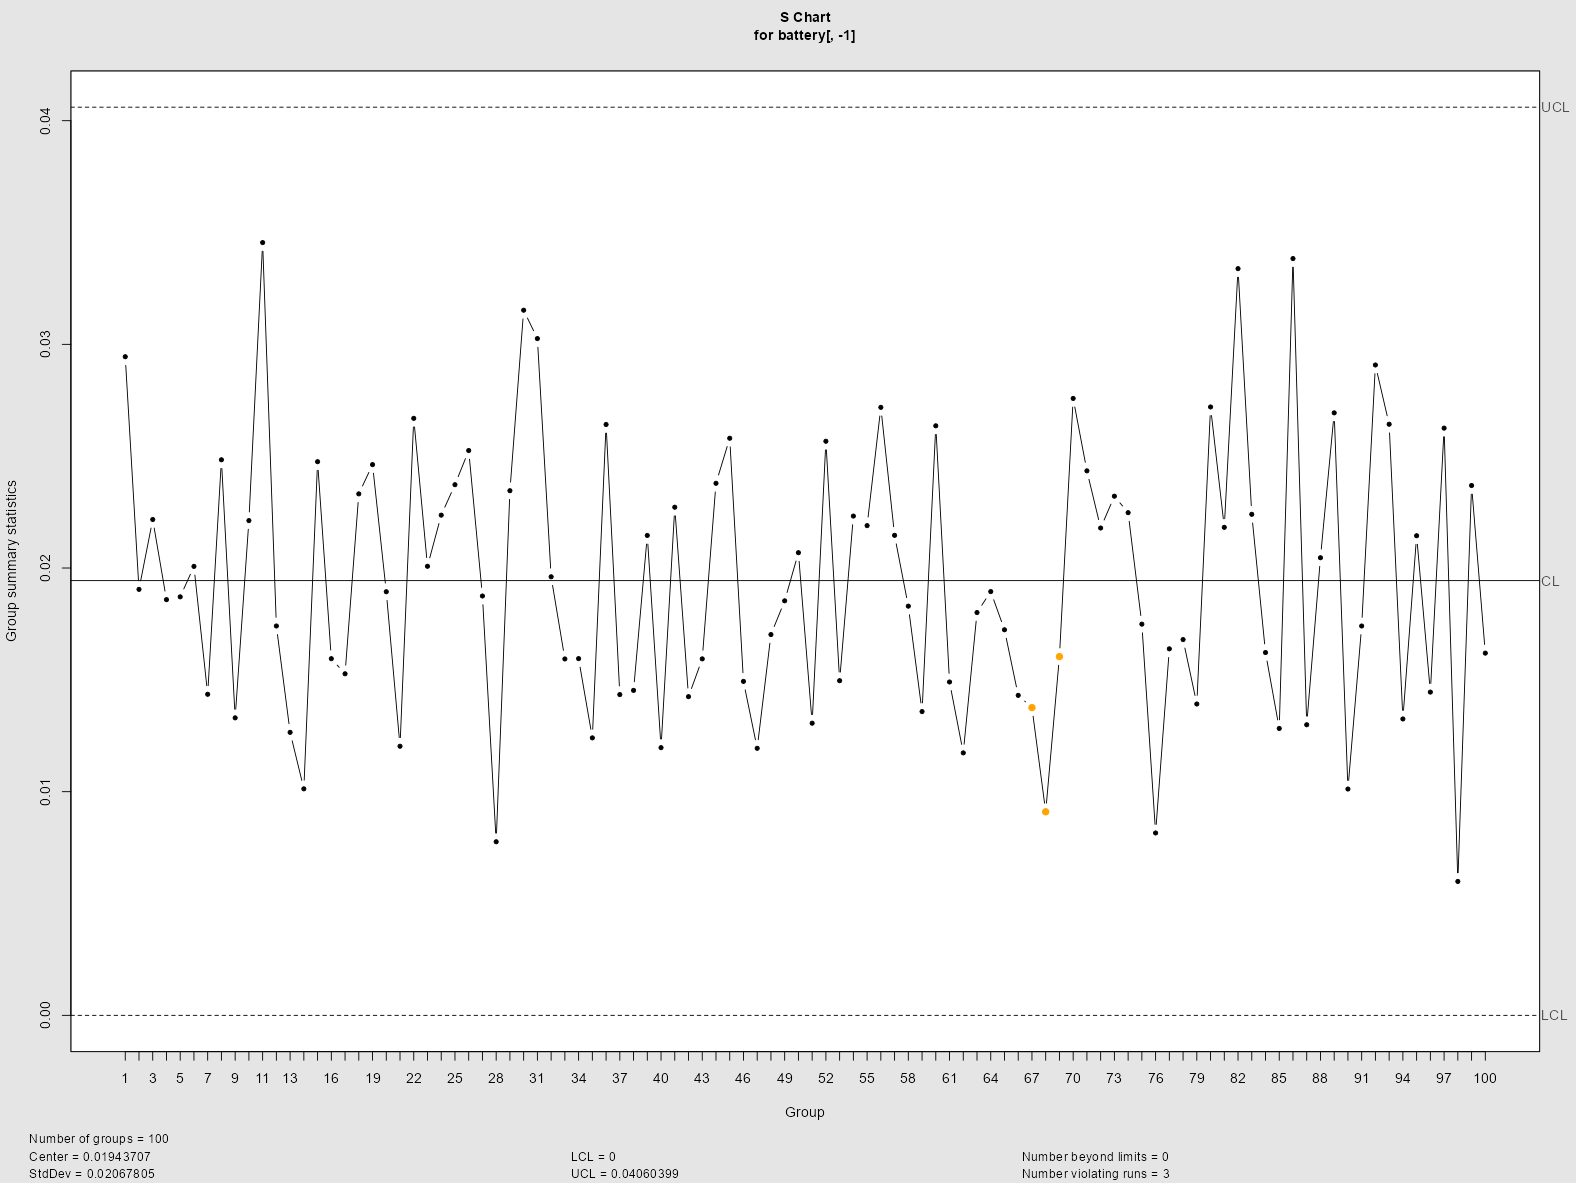

List of 11
 $ call      : language qcc(data = battery[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "battery[, -1]"
 $ data      : num [1:100, 1:5] 1.52 1.54 1.52 1.52 1.55 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:100] 0.0294 0.019 0.0222 0.0186 0.0187 ...
  ..- attr(*, "names")= chr [1:100] "1" "2" "3" "4" ...
 $ sizes     : int [1:100] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0194
 $ std.dev   : num 0.0207
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0406
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

In [16]:
## Generate Phase I X-Bar & S Charts ##

sig_hat <- sd.xbar(battery[,-1])

p1x <- qcc(battery[,-1],type="xbar",std.dev=sig_hat,plot=TRUE)

qcc(battery[,-1],type="S",plot=TRUE)

## Okay good! It looks like the process is in-control. Now,
## let's calculate Cp ##


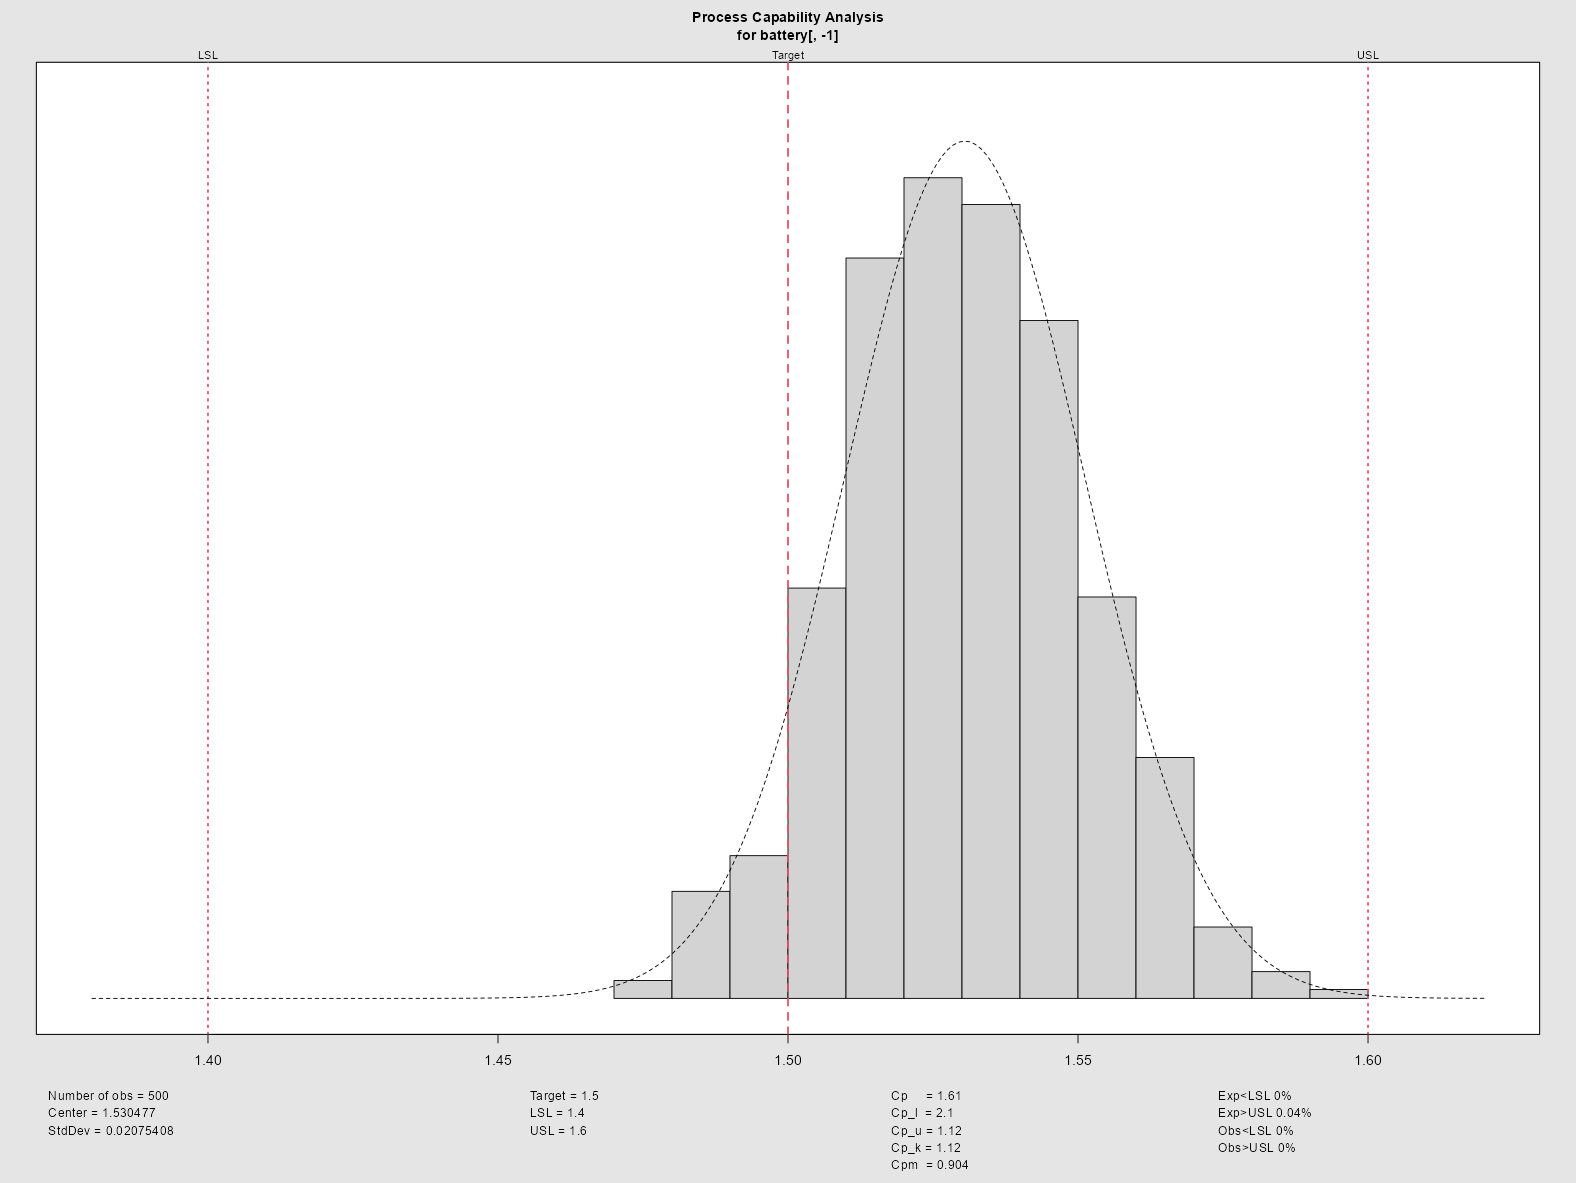


Process Capability Analysis

Call:
process.capability(object = p1x, spec.limits = c(1.4, 1.6), target = 1.5,     nsigmas = 3)

Number of obs = 500          Target = 1.5
       Center = 1.53            LSL = 1.4
       StdDev = 0.02075         USL = 1.6

Capability indices:

      Value    2.5%   97.5%
Cp    1.606  1.5065  1.7057
Cp_l  2.096  1.9838  2.2074
Cp_u  1.117  1.0535  1.1797
Cp_k  1.117  1.0414  1.1918
Cpm   0.904  0.8313  0.9766

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0.04%	 Obs>USL 0%


In [17]:
## Cp ##

process.capability(p1x,spec.limits=c(1.4,1.6),target=1.5,nsigmas=3)

## Cp = 1.61, which means that the difference between USL & LSL is 1.61 times
## the difference between UCL & LCL. This is good, but as we can see from the
## histogram, misleading. ##

## FNC ##
## From the chart, Exp<LSL + Exp>USL = 0.04% = 0.0004. This is good. ##

## Cpk ##

## From the chart, we can see that Cpk is 1.12, which is potentially okay,
## but certainly not as positive of a picture as Cp was giving to us ##


### The $C_{pm}$ index

So far, we've seen how to use the $C_p$ and $C_{pk}$ indices to measure process capability. However, there is another index: the $C_{pm}$ index.

With $C_p$ and $C_{pk}$, we account for the process's variability through our estimate $\hat{\sigma} = \bar{s}/c_4$. However, we don't account for the process's centering, which we can quantify by $\bar{\bar{x}} - \text{Target}$ (sometimes we just use $T$ to mean "Target").

This is where the $C_{pm}$ index comes in:

$$ \hat{C}_{pm} = \frac{USL - LSL}{6\sqrt{\hat{\sigma}^2 + (\bar{\bar{x}} - T)^2}} $$

Here, we can use $s^2 = \hat{\sigma}^2$.

With this measure, we penalize the process for being off-center in our estimate of the process's capability. As the process becomes more off-centered — i.e., as $\bar{\bar{x}}$ moves further from the target value $T$ — the $C_{pm}$ index decreases, giving an indication of poorer process capability compared to $C_p$ and $C_{pk}$.

In the `process.capability` function in R, $C_{pm}$ is output by default. In the Battery Voltage example, $C_{pm} < C_{pk} < C_p$. Since $C_{pm} < 1$ in this case, we would say the process is incapable.

*Note:* there is also a metric called $C_{pmk}$, which is calculated similarly to $C_{pk}$ but with $C_{pm}$ in place of $C_p$.


## Conclusion

- In this class, we learned how to use the sample variance, $s^2$, and sample standard deviation, $s$, when working with Shewhart $\bar{X}$-charts, in addition to learning about additional useful techniques in process capability.
- We also learned about the $C_{pk}$ and $C_{pm}$ indices and how they can be used to measure process capability.
- **Next class:** we will learn about the CUSUM and EWMA control charts as alternatives to the Shewhart $\bar{X}$ chart for monitoring a univariate continuous process.
